## Test model performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tabulate import tabulate
import math

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

In [2]:
# Metaclip base patch 32
val_mc_b_32 = pd.read_csv("vit_base_patch32_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test_mc_b_32 = pd.read_csv('vit_base_patch32_clip_quickgelu_224_metaclip_400m_ForenSynths.csv')

# Metaclip huge patch 14
val_mc_h_14 = pd.read_csv("vit_huge_patch14_clip_quickgelu_224_metaclip_2pt5b_Imagenet.csv")
test_mc_h_14 = pd.read_csv('./outputs/teja_results_shared/vit_huge_patch14_clip_quickgelu_224_metaclip_2pt5b_ForenSynths.csv')

# dinov2 large here
val_dino2_l_14 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/vit_large_patch14_dinov2_lvd142m_Imagenet.csv")
test_dino2_l_14 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/outputs/teja_results_shared/vit_large_patch14_dinov2_lvd142m_ForenSynths.csv")

# dinov3 large patch 16
val_dino3_l_16 = pd.read_csv("vit_large_patch16_dinov3_lvd1689m_Imagenet.csv")
test_dino3_l_16 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/outputs/teja_results_shared/vit_large_patch16_dinov3_lvd1689m.csv")

# Metaclip large patch 14
val_mc_l_14 = pd.read_csv("vit_large_patch14_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test_mc_l_14 = pd.read_csv("vit_large_patch14_clip_quickgelu_224_metaclip_400m_ForenSynths.csv")


# Additional backbones

# dinov3 base
val_dino3_b_16 = pd.read_csv("vit_base_patch16_dinov3_lvd1689m_Imagenet_val.csv")
test_dino3_b_16 = pd.read_csv("vit_base_patch16_dinov3_lvd1689m_ForenSynths.csv")

# dinov2 base
val_dino2_b_14 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/vit_base_patch14_dinov2_lvd142m_Imagenet.csv")
# there is an error in the script
#test_dino2_b_14 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/outputs/teja_results_shared/vit_base_patch14_dinov2_lvd142m_ForenSynths.csv")

# metaclip base patch 16
val_mc_b_16 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/vit_base_patch16_clip_224_metaclip_400m_Imagenet.csv")
test_mc_b_16 = pd.read_csv("/home/tischuet/zero-shot-deepfake-detection/outputs/teja_results_shared/vit_base_patch16_clip_224_metaclip_400m.csv")

In [2]:

with open("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_local_last_layer_ForenSynths.jsonl", "r") as f:
    next(f)
    df = pd.read_json(f, lines=True)

In [3]:
# Assuming your dataframe is called `df`
y_true = df['label']

# Metrics for `score`
auc_score = roc_auc_score(y_true, df['score'])
ap_score = average_precision_score(y_true, df['score'])

# Metrics for `raw_score`
auc_raw = roc_auc_score(y_true, df['raw_score'])
ap_raw = average_precision_score(y_true, df['raw_score'])

print(f"score      -> AUC: {auc_score:.4f}, AP: {ap_score:.4f}")
print(f"raw_score  -> AUC: {auc_raw:.4f}, AP: {ap_raw:.4f}")

score      -> AUC: 0.7563, AP: 0.7693
raw_score  -> AUC: 0.7732, AP: 0.8018


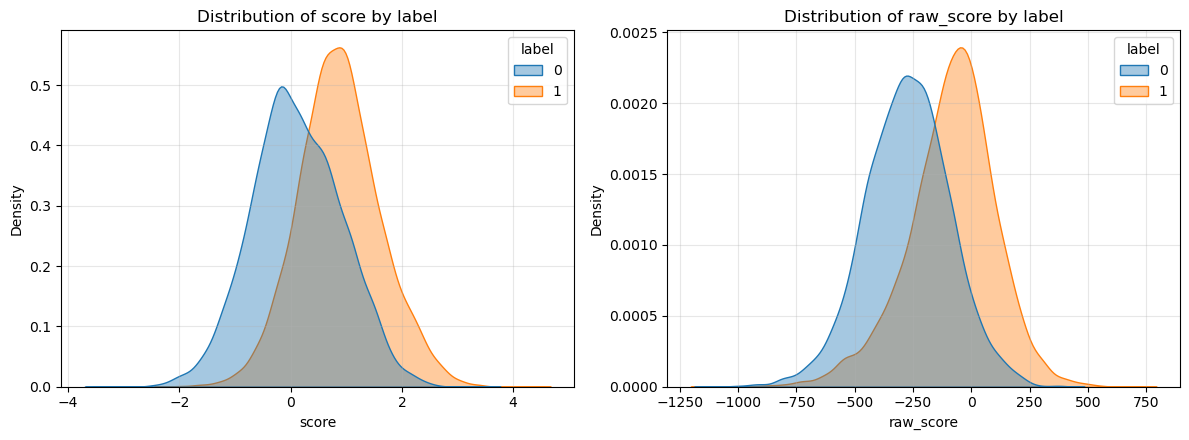

In [4]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, ['score', 'raw_score']):
    sns.kdeplot(data=df, x=col, hue='label', fill=True,
                common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'Distribution of {col} by label')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Number of car samples: 3994
  label=0 (real): 1997
  label=1 (fake): 1997


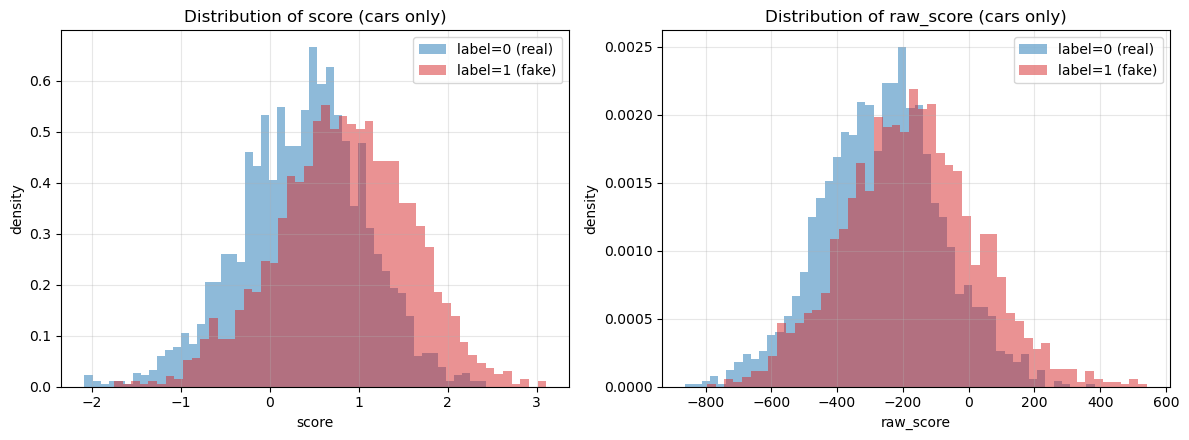

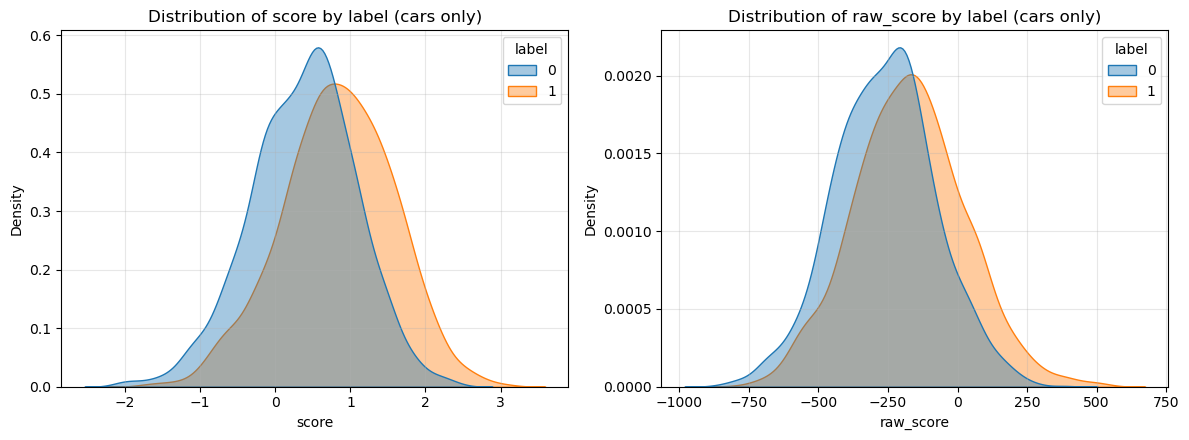

In [5]:
import matplotlib.pyplot as plt

# Filter for car images
df_car = df[df['img_path'].str.contains('car', case=False, na=False)]
print(f"Number of car samples: {len(df_car)}")
print(f"  label=0 (real): {(df_car['label'] == 0).sum()}")
print(f"  label=1 (fake): {(df_car['label'] == 1).sum()}")

# --- Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, ['score', 'raw_score']):
    for label, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        vals = df_car.loc[df_car['label'] == label, col]
        ax.hist(vals, bins=50, alpha=0.5, color=color,
                label=f'label={label} (real)' if label == 0 else f'label={label} (fake)',
                density=True)
    ax.set_title(f'Distribution of {col} (cars only)')
    ax.set_xlabel(col)
    ax.set_ylabel('density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- KDE ---
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, ['score', 'raw_score']):
    sns.kdeplot(data=df_car, x=col, hue='label', fill=True,
                common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'Distribution of {col} by label (cars only)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score

for col in ['score', 'raw_score']:
    auc = roc_auc_score(df_car['label'], df_car[col])
    ap = average_precision_score(df_car['label'], df_car[col])
    print(f"{col:10s} -> AUC: {auc:.4f}, AP: {ap:.4f}")

score      -> AUC: 0.6731, AP: 0.6809
raw_score  -> AUC: 0.6277, AP: 0.6334



=== CAR ===
  total: 3994  |  label=0: 1997  |  label=1: 1997
  score       -> AUC: 0.6731, AP: 0.6809
  raw_score   -> AUC: 0.6277, AP: 0.6334
  local_mean  -> AUC: 0.4306, AP: 0.4617


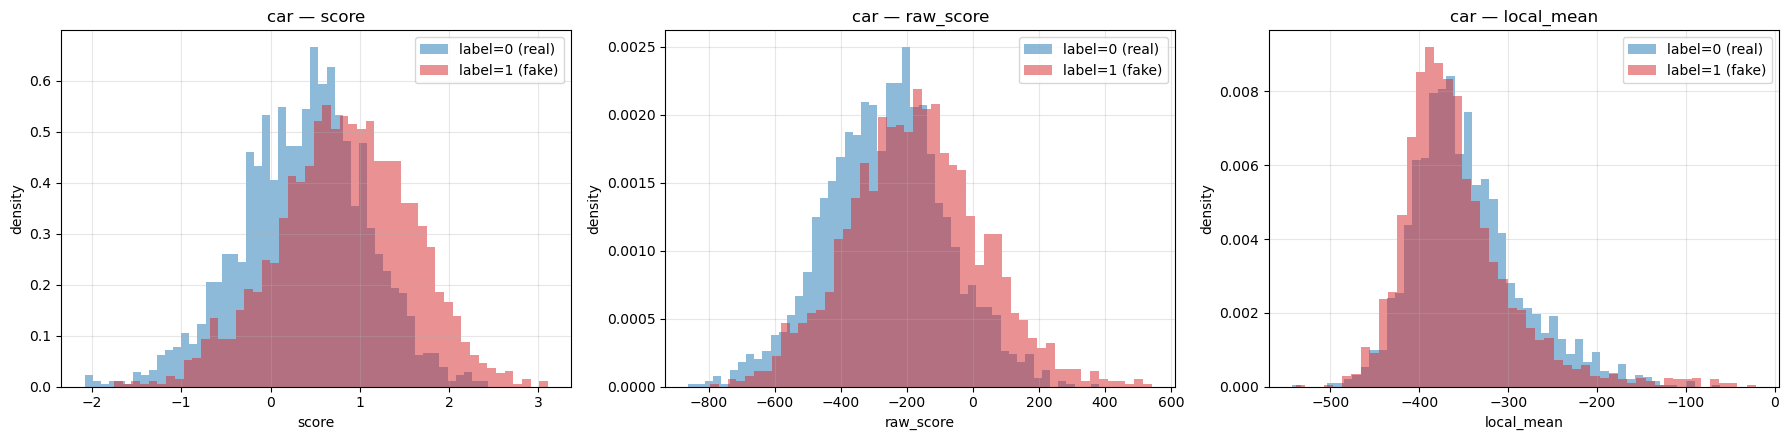

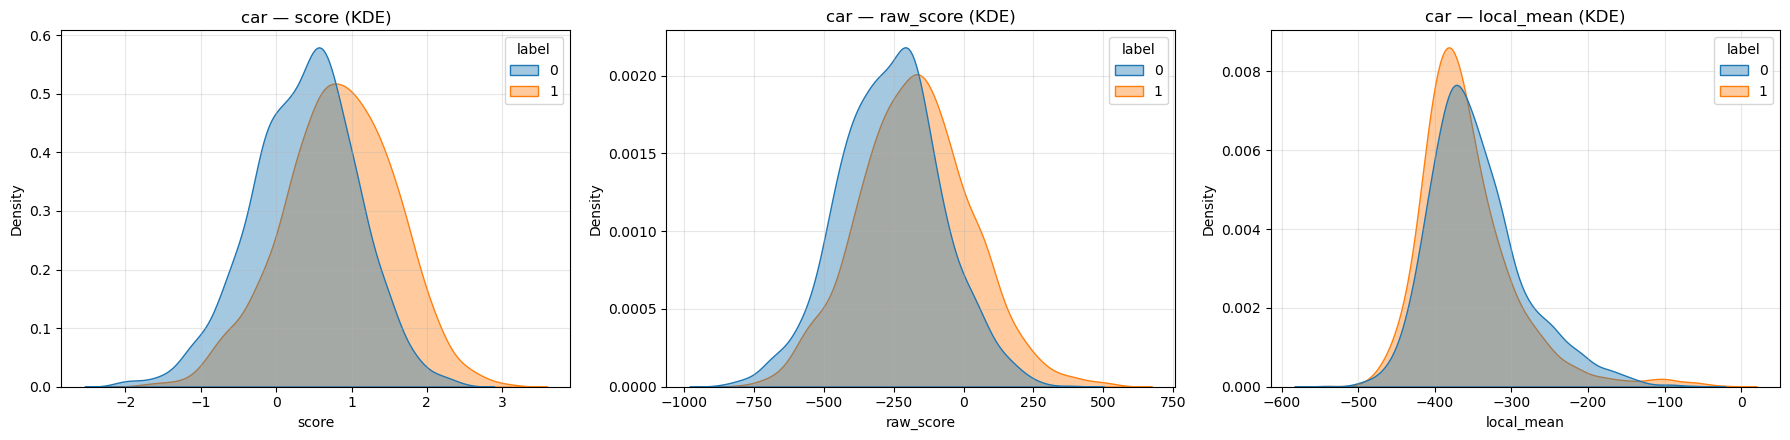


=== CAT ===
  total: 3994  |  label=0: 1997  |  label=1: 1997
  score       -> AUC: 0.7609, AP: 0.7798
  raw_score   -> AUC: 0.7160, AP: 0.7362
  local_mean  -> AUC: 0.4282, AP: 0.4362


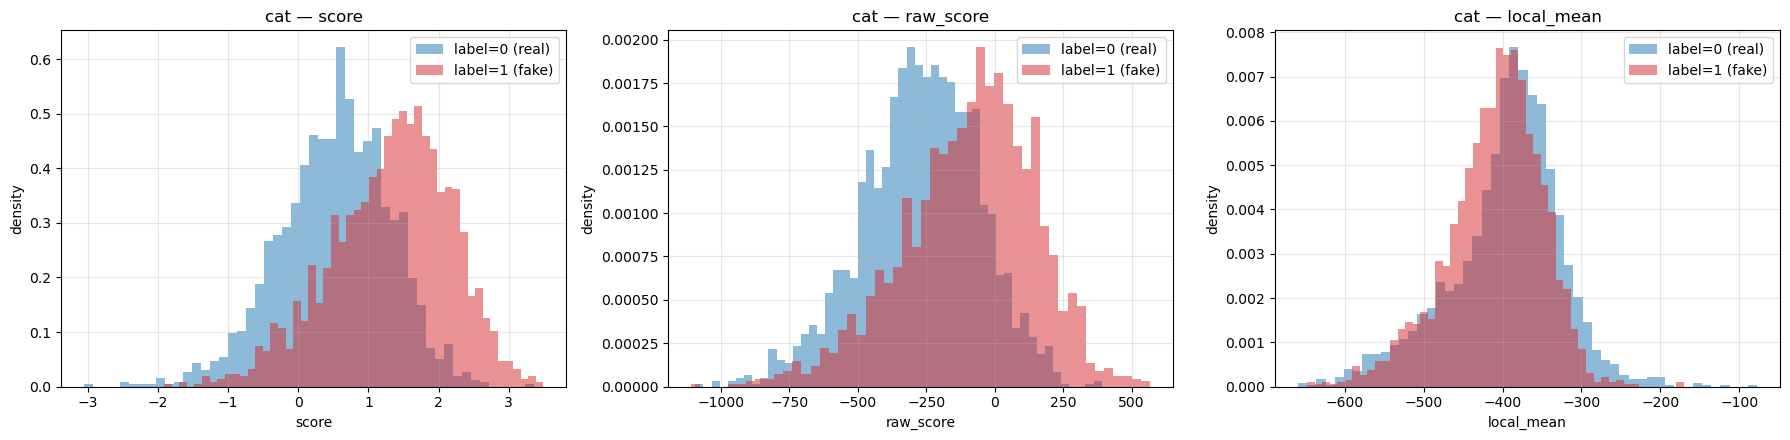

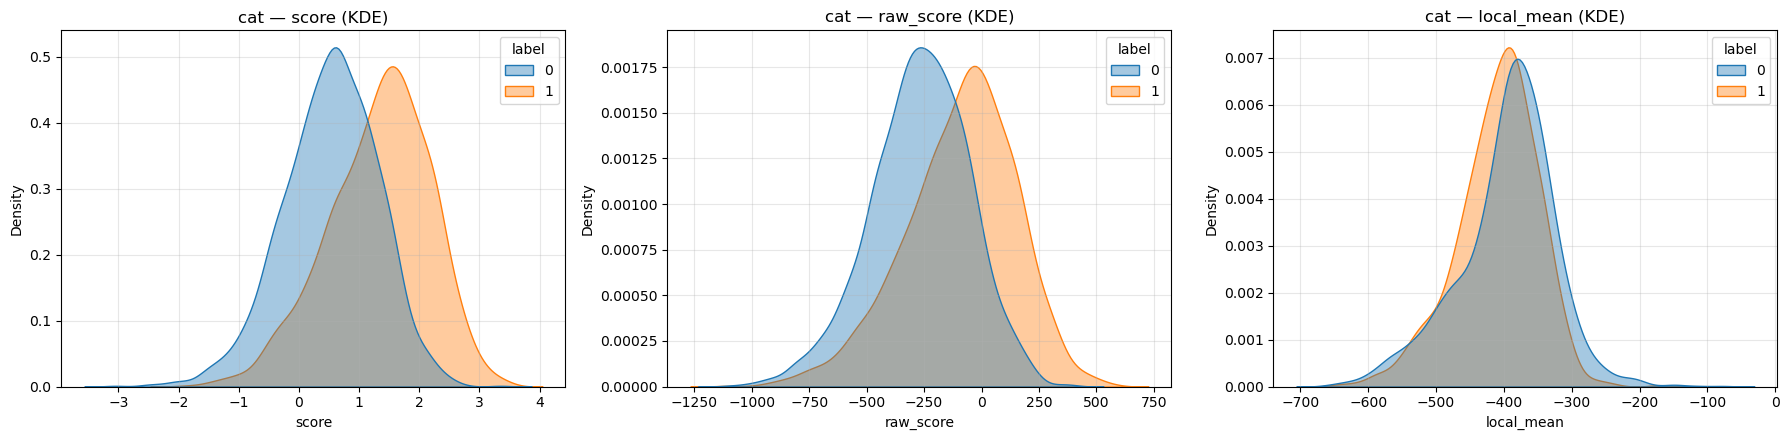


=== BEDROOM ===
  total: 3994  |  label=0: 1997  |  label=1: 1997
  score       -> AUC: 0.8750, AP: 0.8757
  raw_score   -> AUC: 0.8773, AP: 0.8768
  local_mean  -> AUC: 0.6820, AP: 0.6333


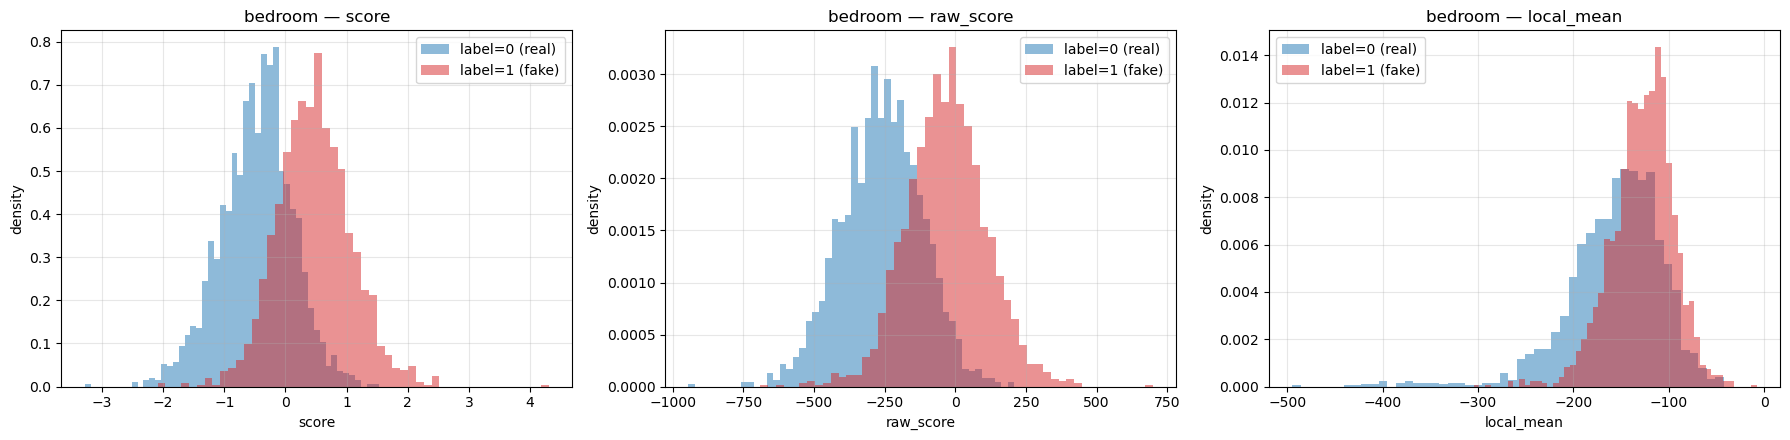

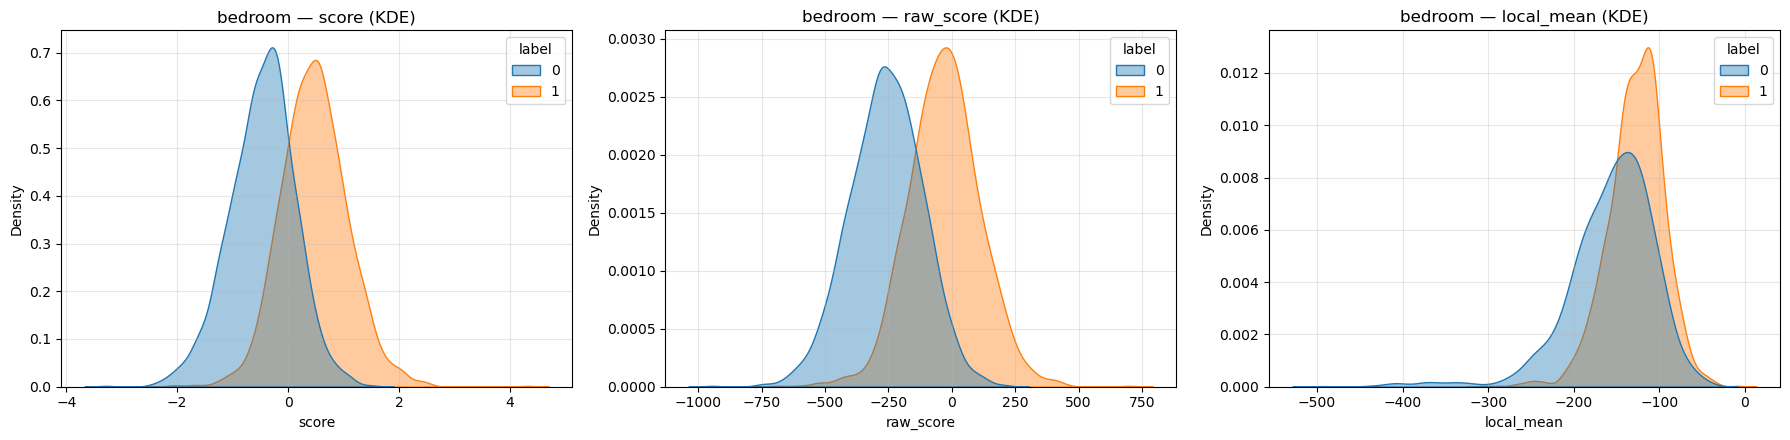


=== STYLEGAN ===
  total: 11982  |  label=0: 5991  |  label=1: 5991
  score       -> AUC: 0.7325, AP: 0.7278
  raw_score   -> AUC: 0.7346, AP: 0.7466
  local_mean  -> AUC: 0.4922, AP: 0.5353


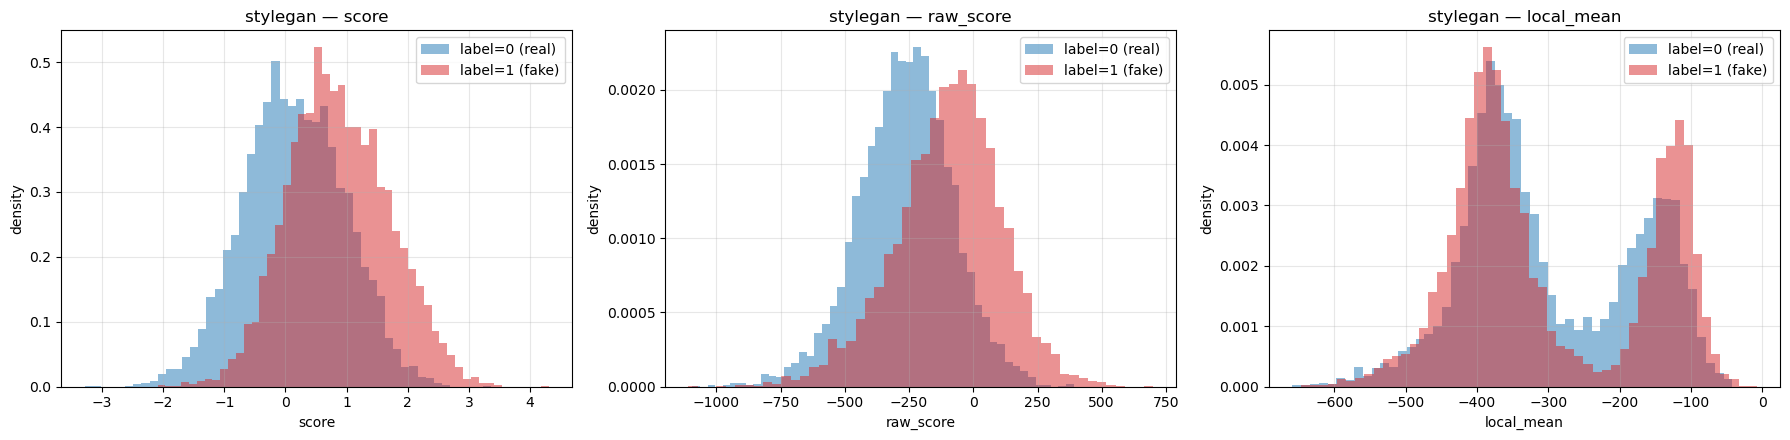

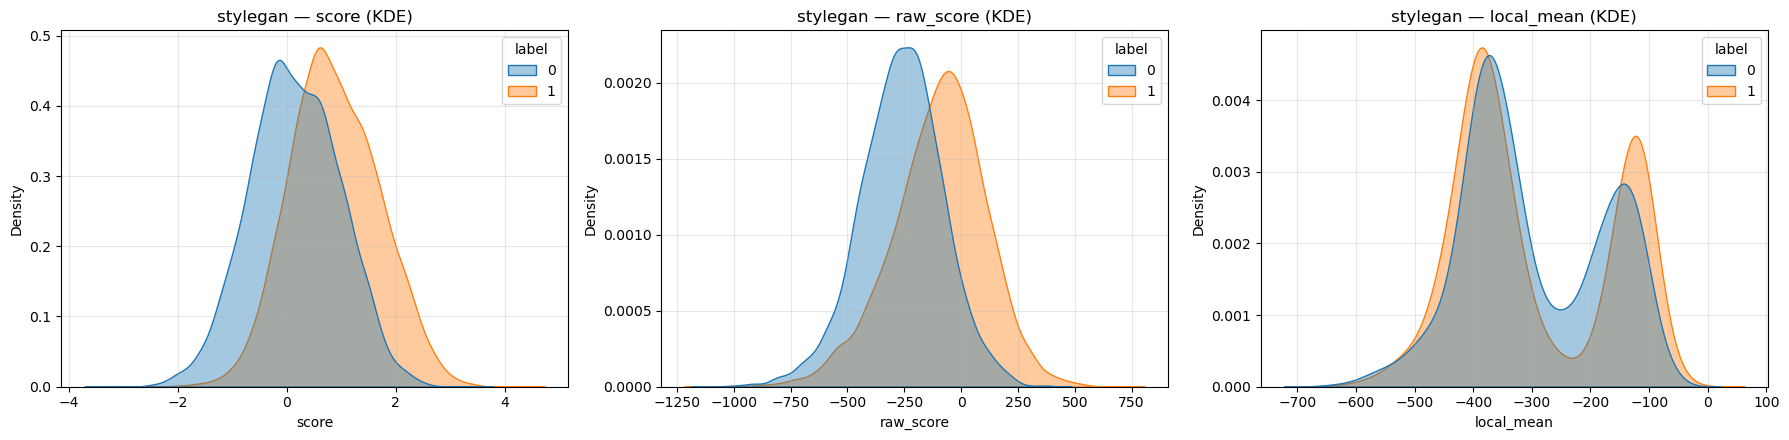

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score

categories = ['car', 'cat', 'bedroom', 'stylegan']
score_cols = ['score', 'raw_score', 'local_mean']

for cat in categories:
    df_sub = df[df['img_path'].str.contains(cat, case=False, na=False)]

    print(f"\n=== {cat.upper()} ===")
    print(f"  total: {len(df_sub)}  |  label=0: {(df_sub['label']==0).sum()}  |  label=1: {(df_sub['label']==1).sum()}")

    if df_sub['label'].nunique() < 2 or len(df_sub) == 0:
        print("  Skipping metrics/plots (need both classes present).")
        continue

    # Metrics
    for col in score_cols:
        auc = roc_auc_score(df_sub['label'], df_sub[col])
        ap = average_precision_score(df_sub['label'], df_sub[col])
        print(f"  {col:11s} -> AUC: {auc:.4f}, AP: {ap:.4f}")

    # Histograms
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for ax, col in zip(axes, score_cols):
        for label, color in [(0, 'tab:blue'), (1, 'tab:red')]:
            vals = df_sub.loc[df_sub['label'] == label, col]
            ax.hist(vals, bins=50, alpha=0.5, color=color,
                    label=f'label={label} ({"real" if label==0 else "fake"})',
                    density=True)
        ax.set_title(f'{cat} — {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('density')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # KDE
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for ax, col in zip(axes, score_cols):
        sns.kdeplot(data=df_sub, x=col, hue='label', fill=True,
                    common_norm=False, alpha=0.4, ax=ax)
        ax.set_title(f'{cat} — {col} (KDE)')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# --- Load a JSONL output file ---
output_path = Path("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_local_last_layer_ForenSynths.jsonl")  # fill in
with open(output_path, "r") as f:
    next(f)  # skip metadata header
    df = pd.read_json(f, lines=True)

# Convert svdvals lists to a [N, K] matrix (sorted descending — torch.linalg.svdvals does this)
S = np.array(df["svdvals"].tolist(), dtype=np.float64)  # [N, K]
N, K = S.shape
print(f"N={N}, K={K}")

eps = 1e-6
logS = np.log(np.clip(S, eps, None))   # [N, K]

# Optional: filter for a content class
def subset(cat):
    m = df["img_path"].str.contains(cat, case=False, na=False)
    return df[m].reset_index(drop=True), S[m.values], logS[m.values]

def auc_ap(y, s):
    auc = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    if auc < 0.5:
        return roc_auc_score(y, -s), average_precision_score(y, -s), True
    return auc, ap, False

N=15592, K=768


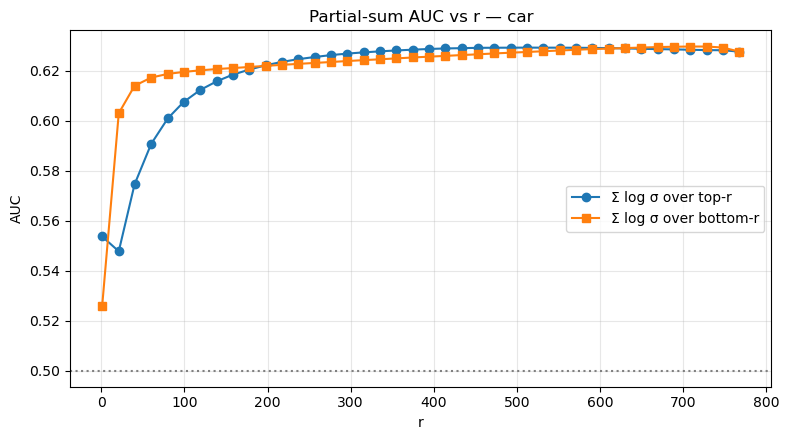

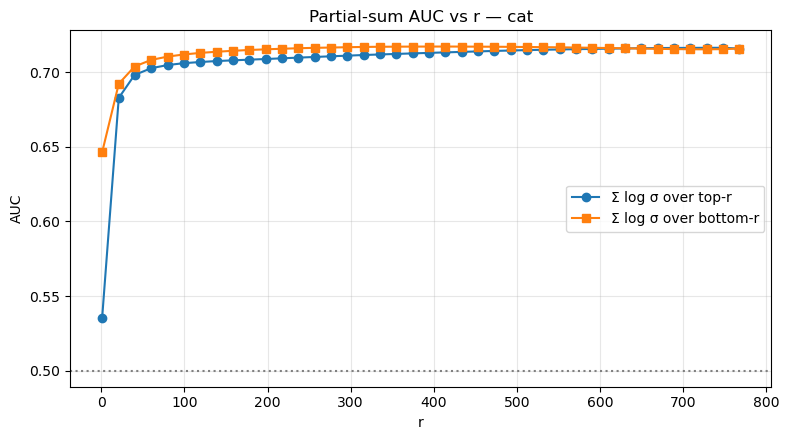

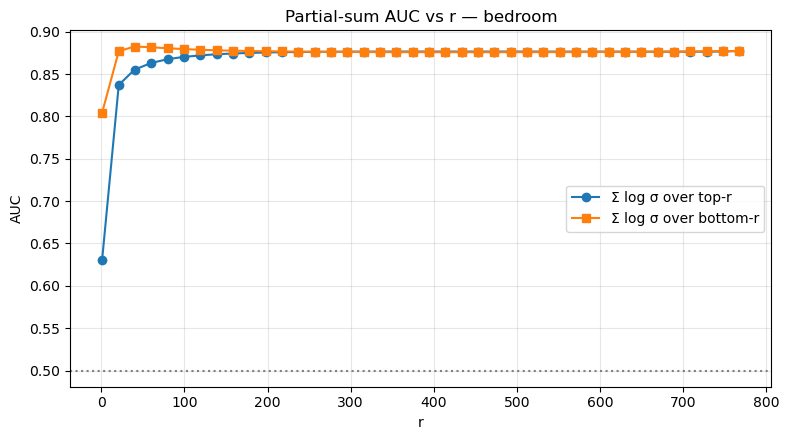

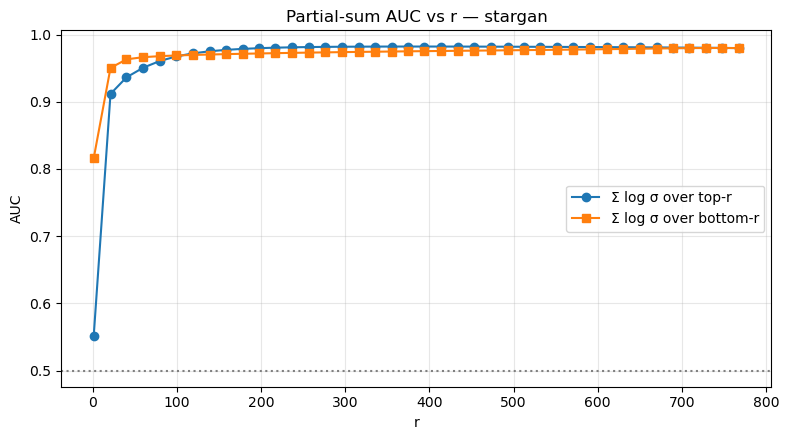

In [13]:
def partial_sum_sweep(df_sub, logS_sub, name):
    y = df_sub["label"].values
    K = logS_sub.shape[1]
    cum_from_top = np.cumsum(logS_sub, axis=1)            # sum of top-r log σ
    cum_from_tail = np.cumsum(logS_sub[:, ::-1], axis=1)  # sum of bottom-r log σ

    rs = np.unique(np.round(np.linspace(1, K, 40)).astype(int))
    aucs_top, aucs_tail = [], []
    for r in rs:
        a_t, _, _ = auc_ap(y, cum_from_top[:, r-1])
        a_b, _, _ = auc_ap(y, cum_from_tail[:, r-1])
        aucs_top.append(a_t); aucs_tail.append(a_b)

    plt.figure(figsize=(8, 4.5))
    plt.plot(rs, aucs_top,  label="Σ log σ over top-r", marker='o')
    plt.plot(rs, aucs_tail, label="Σ log σ over bottom-r", marker='s')
    plt.axhline(0.5, ls=':', color='gray')
    plt.xlabel("r")
    plt.ylabel("AUC")
    plt.title(f"Partial-sum AUC vs r — {name}")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return rs, aucs_top, aucs_tail

for cat in ["car", "cat", "bedroom", "stargan"]:
    d, _, lS = subset(cat)
    if d["label"].nunique() == 2:
        partial_sum_sweep(d, lS, cat)

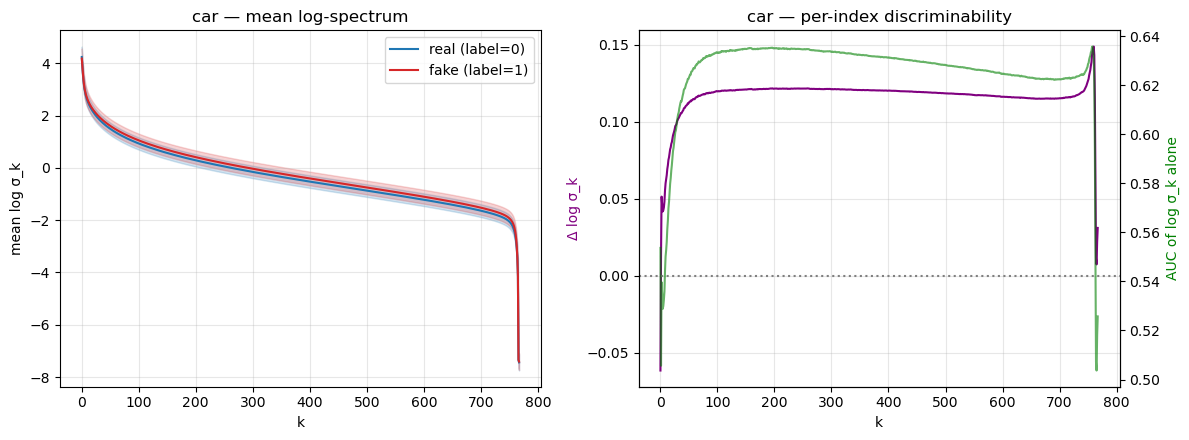

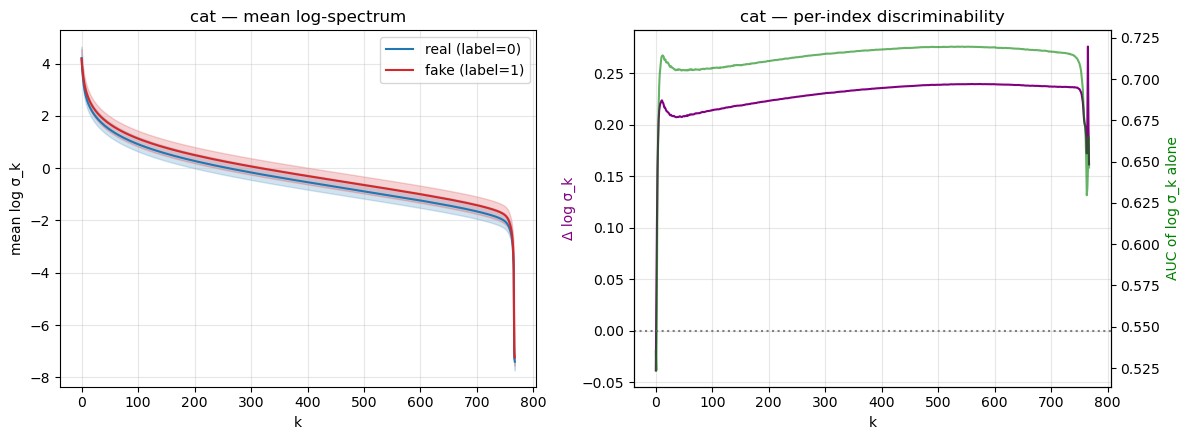

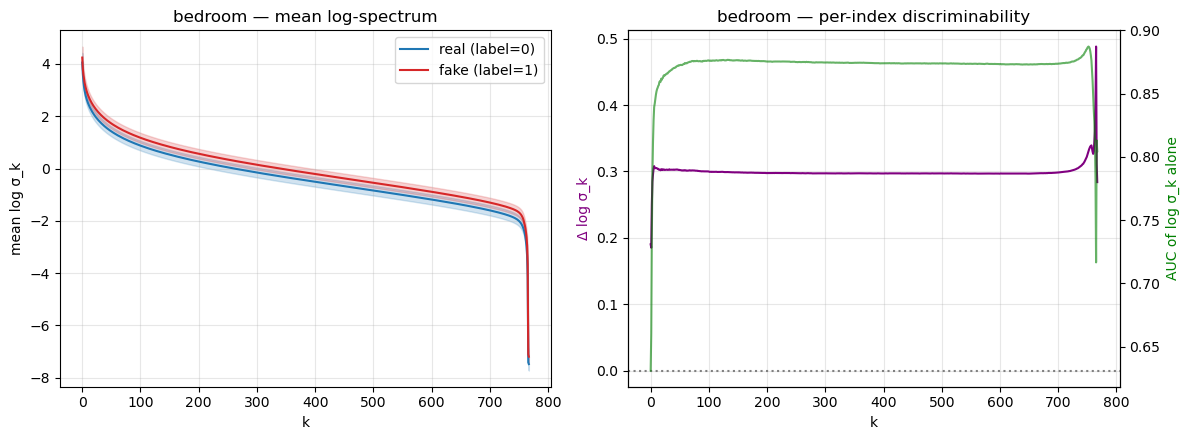

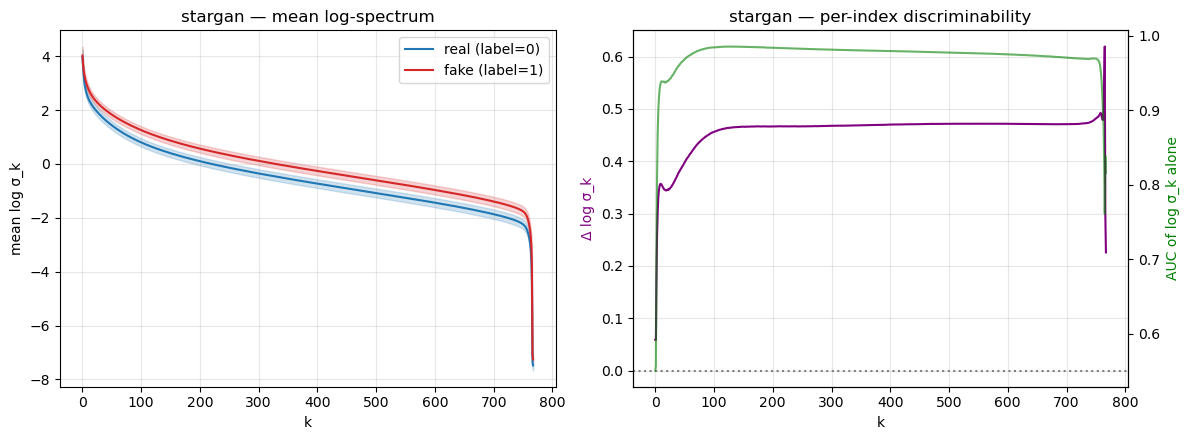

In [15]:
def plot_mean_spectrum(df_sub, logS_sub, name):
    y = df_sub["label"].values
    mean_real = logS_sub[y == 0].mean(axis=0)
    mean_fake = logS_sub[y == 1].mean(axis=0)
    std_real  = logS_sub[y == 0].std(axis=0)
    std_fake  = logS_sub[y == 1].std(axis=0)
    ks = np.arange(len(mean_real))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(ks, mean_real, label="real (label=0)", color="tab:blue")
    axes[0].fill_between(ks, mean_real - std_real, mean_real + std_real, color="tab:blue", alpha=0.2)
    axes[0].plot(ks, mean_fake, label="fake (label=1)", color="tab:red")
    axes[0].fill_between(ks, mean_fake - std_fake, mean_fake + std_fake, color="tab:red", alpha=0.2)
    axes[0].set_xlabel("k"); axes[0].set_ylabel("mean log σ_k")
    axes[0].set_title(f"{name} — mean log-spectrum")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Difference + per-index AUC, the actually useful view
    diff = mean_fake - mean_real
    per_k_auc = np.array([roc_auc_score(y, logS_sub[:, k]) for k in range(len(ks))])
    per_k_auc = np.where(per_k_auc < 0.5, 1 - per_k_auc, per_k_auc)  # absolute discriminability

    ax2 = axes[1]
    ax2.plot(ks, diff, color="purple", label="mean(fake) − mean(real)")
    ax2.set_xlabel("k"); ax2.set_ylabel("Δ log σ_k", color="purple")
    ax2.axhline(0, ls=':', color='gray')
    ax3 = ax2.twinx()
    ax3.plot(ks, per_k_auc, color="green", alpha=0.6, label="per-index |AUC−0.5|+0.5")
    ax3.set_ylabel("AUC of log σ_k alone", color="green")
    ax2.set_title(f"{name} — per-index discriminability")
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

for cat in ["car", "cat", "bedroom", "stargan"]:
    d, S_sub, lS_sub = subset(cat)
    if d["label"].nunique() == 2:
        plot_mean_spectrum(d, lS_sub, cat)

# Test this

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# --- 1. Load calibration set (real ImageNet-val) ---
cal_path = Path("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_last_layer_Imagenet_val_5k.jsonl")  # fill in
with open(cal_path) as f:
    next(f)  # skip metadata
    cal_df = pd.read_json(f, lines=True)

cal_S = np.array(cal_df["svdvals"].tolist(), dtype=np.float64)        # [N_cal, K]
cal_emb = np.array(cal_df["embedding"].tolist(), dtype=np.float32)    # [N_cal, D]
cal_emb /= np.linalg.norm(cal_emb, axis=1, keepdims=True) + 1e-12     # L2-normalize

eps = 1e-6
cal_logS = np.log(np.clip(cal_S, eps, None))  # [N_cal, K]
print(f"Calibration: {cal_S.shape[0]} images, K={cal_S.shape[1]}")

# --- 2. Load test set (ForenSynths) ---
test_path = Path("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_local_last_layer_ForenSynths.jsonl")  # fill in
with open(test_path) as f:
    next(f)
    test_df = pd.read_json(f, lines=True)

test_S = np.array(test_df["svdvals"].tolist(), dtype=np.float64)
test_logS = np.log(np.clip(test_S, eps, None))

# Your conditional-z file doesn't have embeddings, but it has local_mean/local_std
# already computed for the SCALAR score. For PER-INDEX normalization, we need to
# re-find the k-NN. Two options:
#   (A) If you saved embeddings in the test file too, use those.
#   (B) Otherwise, you need to recompute embeddings — but you can skip that by
#       running the cheaper inference-only pass (no Jacobian) on the test images.
#
# For now, assume option (A) — embeddings present. If not, the same approach
# works but you'll need to recompute embeddings only.

assert "embedding" in test_df.columns, (
    "Test file doesn't have embeddings. Either rerun test-time scoring with "
    "embeddings saved, or do a cheap inference-only pass to get them."
)
test_emb = np.array(test_df["embedding"].tolist(), dtype=np.float32)
test_emb /= np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12

# --- 3. Find k-NN in calibration for each test sample (cosine sim) ---
k = 100
sims = test_emb @ cal_emb.T                                # [N_test, N_cal]
topk_idx = np.argpartition(-sims, kth=k, axis=1)[:, :k]    # [N_test, k]

# --- 4. Per-index normalization: subtract neighborhood mean log-spectrum ---
# For each test image i, compute mean_logS over its k neighbors → [K]
# Then test_logS_normed[i] = test_logS[i] - neighbor_mean_logS[i]
neighbor_mean = cal_logS[topk_idx].mean(axis=1)            # [N_test, K]
neighbor_std  = cal_logS[topk_idx].std(axis=1) + 1e-8

test_logS_centered = test_logS - neighbor_mean             # subtractive
test_logS_zscored  = (test_logS - neighbor_mean) / neighbor_std  # per-index z

# --- 5. Re-aggregate into scores and evaluate ---
def auc_ap(y, s):
    auc = roc_auc_score(y, s)
    ap = average_precision_score(y, s)
    if auc < 0.5:
        return roc_auc_score(y, -s), average_precision_score(y, -s), True
    return auc, ap, False

y = test_df["label"].values.astype(int)

scores = {
    "full sum (original)":      test_logS.sum(axis=1),
    "centered sum":             test_logS_centered.sum(axis=1),
    "z-scored sum":             test_logS_zscored.sum(axis=1),
    "z-scored mean":            test_logS_zscored.mean(axis=1),
    "z-scored, bulk only (20..740)":  test_logS_zscored[:, 20:740].sum(axis=1),
    "centered, bulk only":      test_logS_centered[:, 20:740].sum(axis=1),
}

print("\n=== OVERALL ===")
for name, s in scores.items():
    auc, ap, flipped = auc_ap(y, s)
    tag = " (flipped)" if flipped else ""
    print(f"  {name:34s} -> AUC: {auc:.4f}, AP: {ap:.4f}{tag}")

print("\n=== PER CATEGORY ===")
for cat in ["car", "cat", "bedroom", "stargan"]:
    mask = test_df["img_path"].str.contains(cat, case=False, na=False).values
    if mask.sum() == 0 or len(np.unique(y[mask])) < 2:
        continue
    print(f"\n--- {cat} (n={mask.sum()}) ---")
    for name, s in scores.items():
        auc, ap, flipped = auc_ap(y[mask], s[mask])
        tag = " (flipped)" if flipped else ""
        print(f"  {name:34s} -> AUC: {auc:.4f}, AP: {ap:.4f}{tag}")

Calibration: 5000 images, K=768


AssertionError: Test file doesn't have embeddings. Either rerun test-time scoring with embeddings saved, or do a cheap inference-only pass to get them.

In [3]:
def plot_per_generator(ds_val, test_results, mean_plus_std, mean_minus_std, percentile, generators):
    n_cols = 4
    n_rows = math.ceil(len(generators) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), sharey=False)
    axes = axes.flatten()

    real_scores = ds_val.score

    for idx, gen in enumerate(generators):
        ax = axes[idx]
        subset = test_results[test_results["img_path"].str.contains(gen)]

        ax.hist(real_scores, bins=100, alpha=0.5, label="val")
        ax.hist(subset[subset["label"] == 1.0].score, bins=100, alpha=0.5, label="fake")
        ax.hist(subset[subset["label"] == 0.0].score, bins=100, alpha=0.5, label="real")
        ax.axvline(x=mean_plus_std,  color="red",   linestyle="--", label="mean+std")
        ax.axvline(x=mean_minus_std, color="green",  linestyle="--", label="mean-std")
        ax.axvline(x=percentile,     color="black",  linestyle="--", label="percentile")

        ax.set_title(gen)
        ax.set_xlabel("JEPA score")
        ax.set_ylabel("Count")

    # shared legend from last valid axis, placed outside the grid
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.02))

    # hide unused subplots
    for idx in range(len(generators), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle("JEPA Score Distribution per Generator", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [4]:
def results(ds_val, test_results):
    # --- Validation stats (unchanged) ---
    """ real_scores = ds_val.score
    plt.figure(figsize=(8,5))
    plt.hist(real_scores, bins=50, alpha=0.6, label="real")
    plt.xlabel("JEPA score")
    plt.ylabel("Count")
    plt.title("JEPA score distribution")
    plt.legend()
    plt.show() """

    print('----- Validation Dataset Statistics -----')
    mean = ds_val.score.mean(numeric_only=True)
    std = ds_val.score.std(numeric_only=True)
    mean_plus_std = mean + std
    mean_minus_std = mean - std
    percentile = ds_val.score.quantile(q=0.95)
    print(f"Mean: {mean:.4f}  |  Std: {std:.4f}")
    print(f"Mean+std threshold: {mean_plus_std:.4f}")
    print(f"Mean-std threshold: {mean_minus_std:.4f}")
    print(f"95th percentile threshold: {percentile:.4f}")

    # --- Predictions ---
    test_results["prediction_mean_plus_std"]  = (test_results.score >= mean_plus_std).astype(int)
    test_results["prediction_mean_minus_std"] = (test_results.score >= mean_minus_std).astype(int)
    test_results["prediction_percentile"]     = (test_results.score >= percentile).astype(int)

    # --- Metric collection ---
    def cal_metrics(df):
        """Returns a dict of metrics for a given result dataframe."""
        return {
            "F1 (mean+std)":   round(f1_score(df.label, df.prediction_mean_plus_std),  4),
            "Acc (mean+std)":  round(accuracy_score(df.label, df.prediction_mean_plus_std), 4),
            "F1 (mean-std)":   round(f1_score(df.label, df.prediction_mean_minus_std), 4),
            "Acc (mean-std)":  round(accuracy_score(df.label, df.prediction_mean_minus_std), 4),
            "F1 (percentile)": round(f1_score(df.label, df.prediction_percentile), 4),
            "Acc (percentile)":round(accuracy_score(df.label, df.prediction_percentile), 4),
            "AUC":             round(roc_auc_score(df.label, df.score), 4),
            "Avg Precision":   round(average_precision_score(df.label, df.score), 4),
        }

    # --- Build table rows ---
    rows = {"overall": cal_metrics(test_results)}

    generators = ["biggan", "crn", "cyclegan", "deepfake", "gaugan", "imle",
                  "progan", "san", "seeingdark", "stargan", "stylegan",
                  "stylegan2", "whichfaceisreal"]
    
    plot_per_generator(ds_val, test_results, mean_plus_std, mean_minus_std, percentile, generators)
    
    for gen in generators:
        #subset = test_results[test_results["img_path"].str.contains(gen)].copy()
        subset = test_results[test_results["img_path"].str.split("/").str[0] == gen].copy()
        if not subset.empty:
            rows[gen] = cal_metrics(subset)

    # --- Print as table ---
    headers = ["Subset"] + list(next(iter(rows.values())).keys())
    table   = [[name] + list(metrics.values()) for name, metrics in rows.items()]
    print('\n----- Performance Metrics -----')
    print(tabulate(table, headers=headers, tablefmt="rounded_outline", floatfmt=".4f"))

----- Validation Dataset Statistics -----
Mean: -722.6715  |  Std: 284.5191
Mean+std threshold: -438.1524
Mean-std threshold: -1007.1907
95th percentile threshold: -251.0750


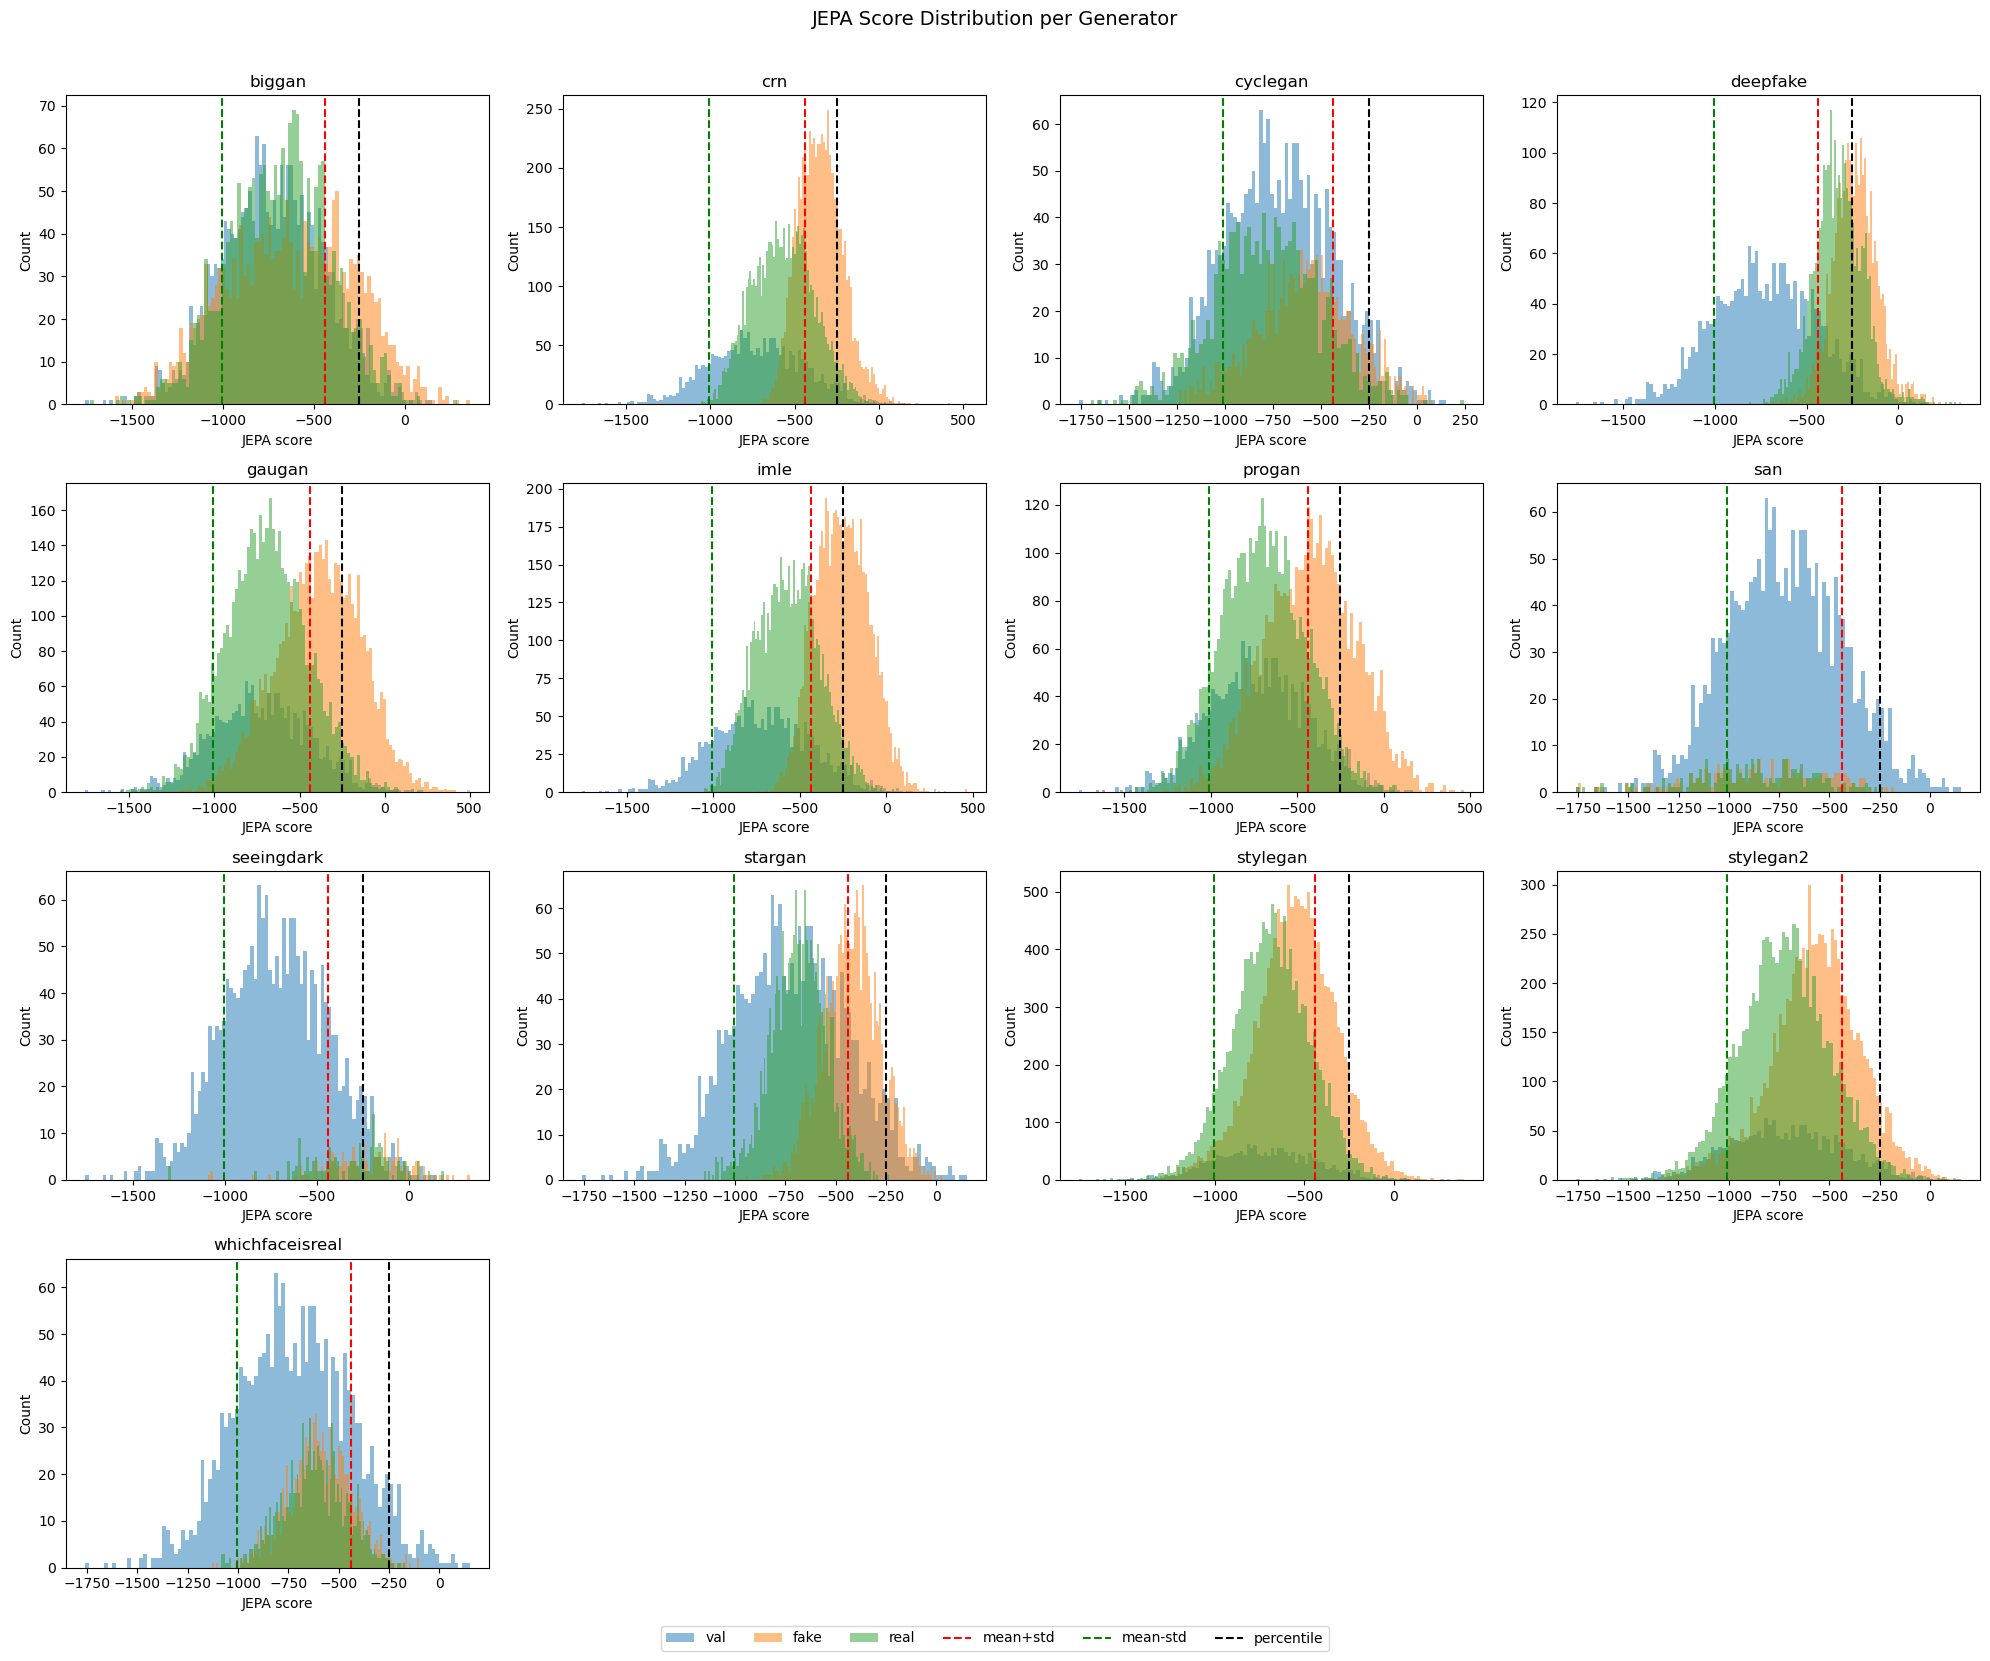


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.6254 │           0.6719 │          0.6700 │           0.5179 │            0.3655 │             0.5937 │ 0.7342 │          0.7353 │
│ biggan          │          0.4340 │           0.5767 │          0.6163 │           0.4808 │            0.2561 │             0.5513 │ 0.5525 │          0.5980 │
│ crn             │          0.7460 │           0.7480 │          0.6670 │           0.5009 │            0.3616 │             0.5930 │ 0.8329 │          0.79

In [5]:
results(ds_val=val_mc_b_32, test_results=test_mc_b_32)

----- Validation Dataset Statistics -----
Mean: -871.8253  |  Std: 570.8009
Mean+std threshold: -301.0244
Mean-std threshold: -1442.6261
95th percentile threshold: 53.1874


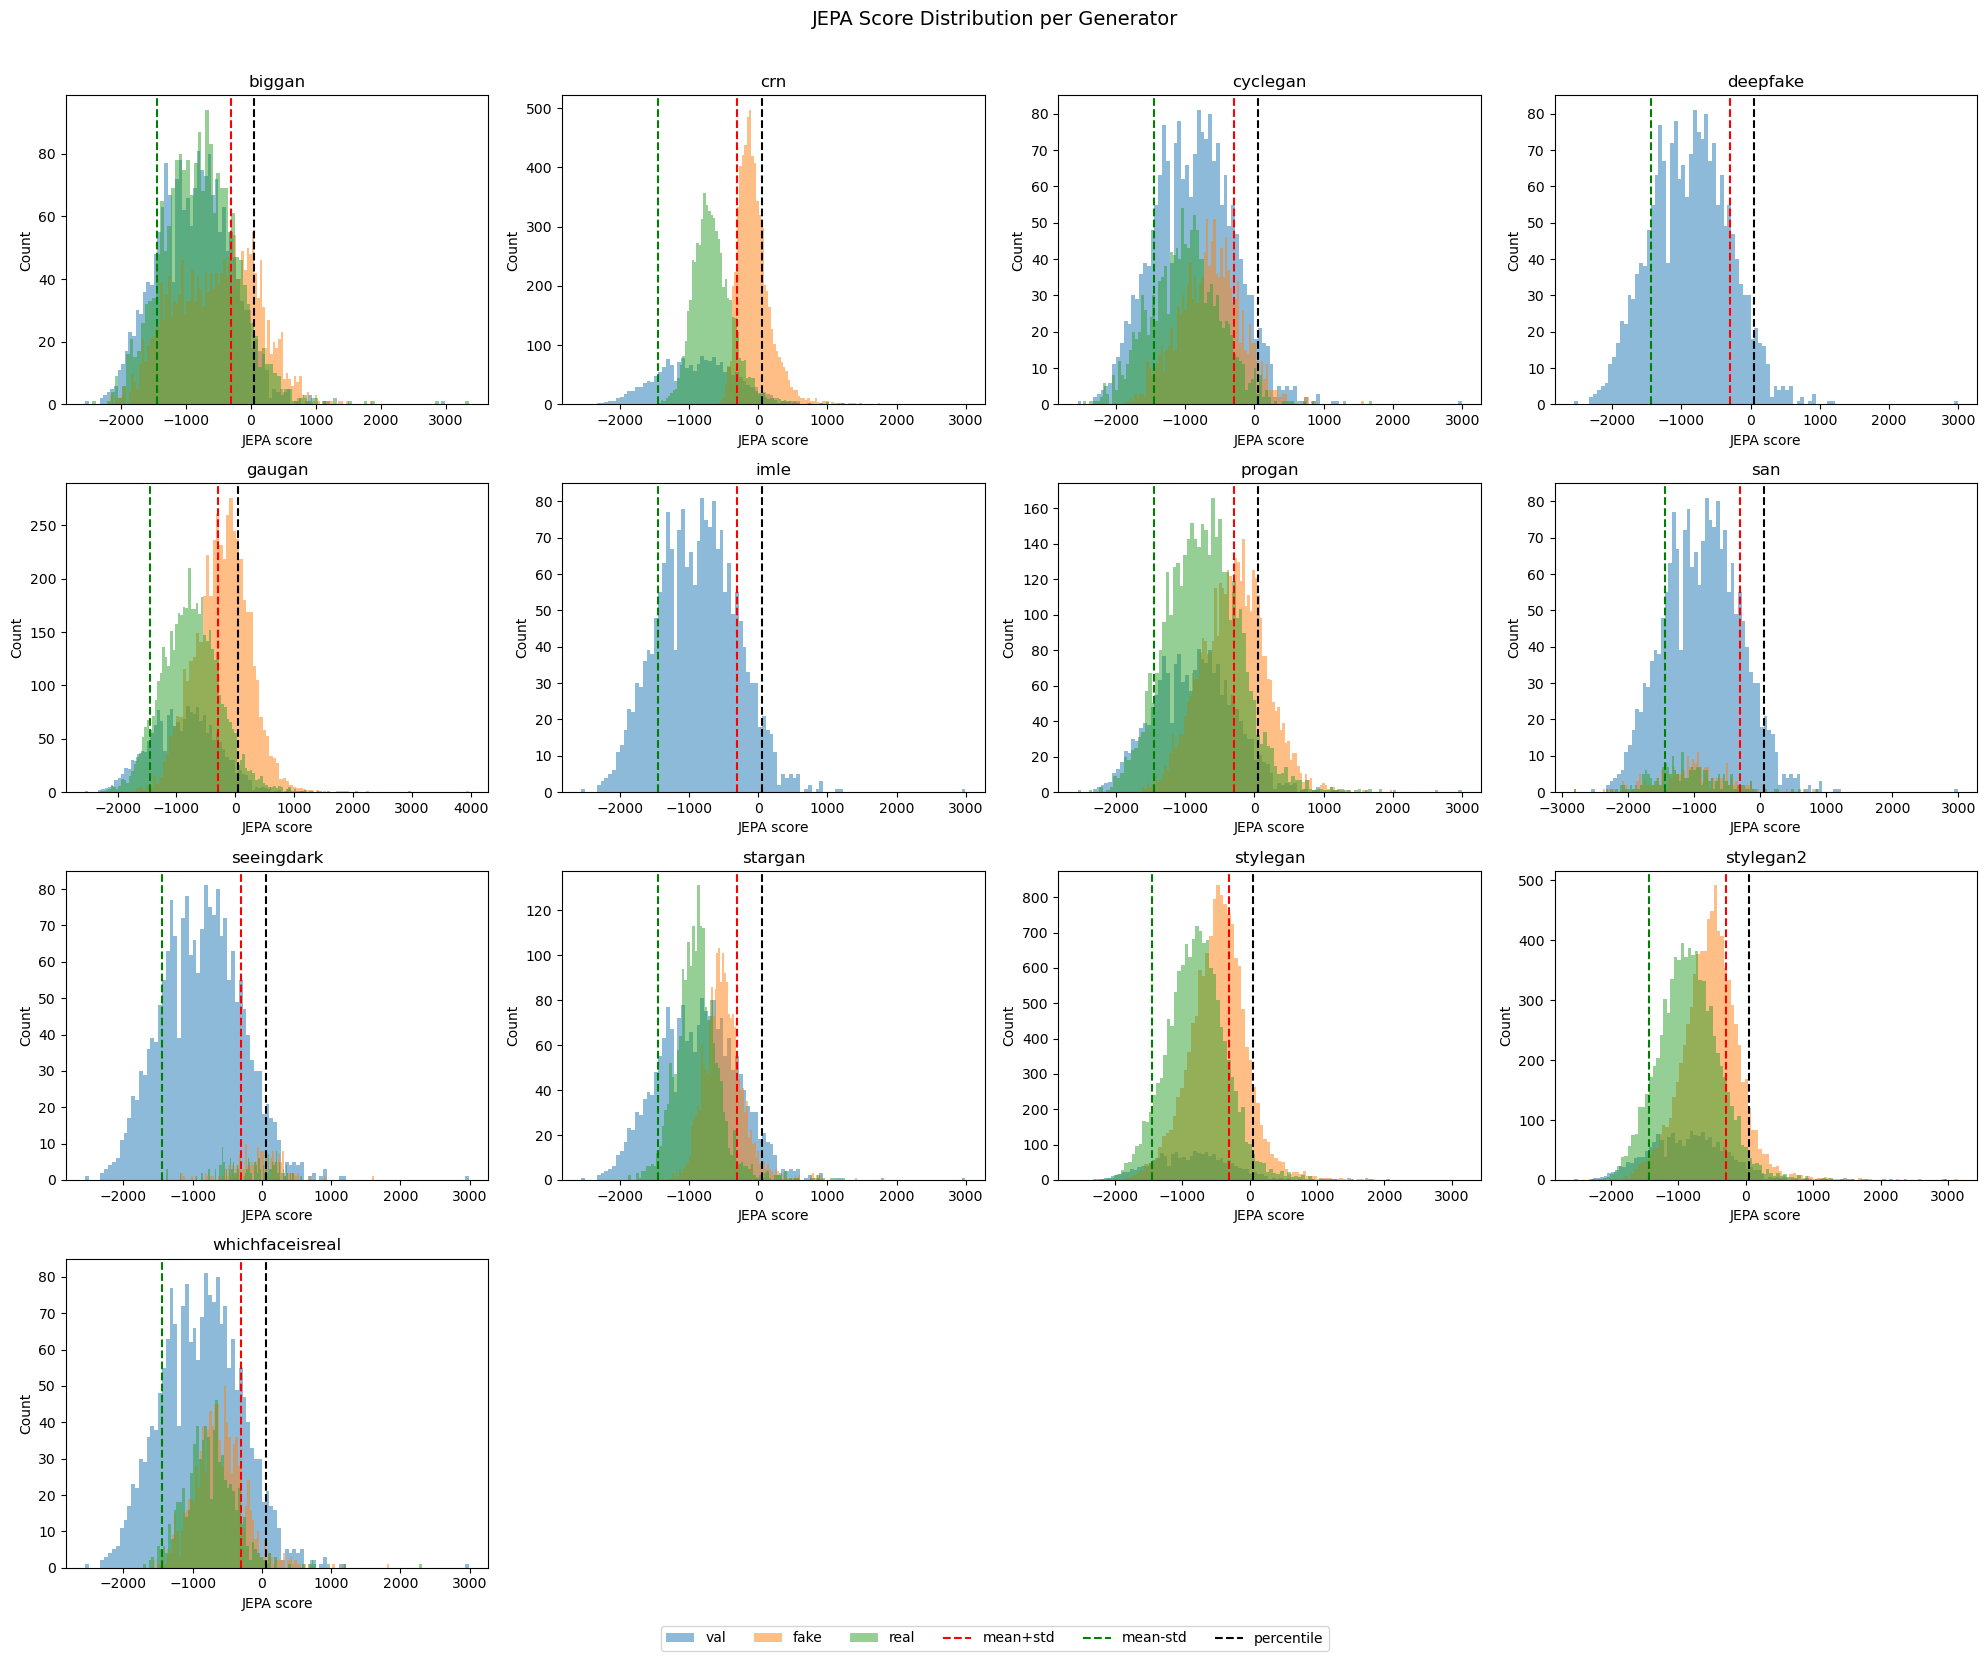


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.5916 │           0.6700 │          0.6764 │           0.5268 │            0.2646 │             0.5584 │ 0.7489 │          0.7225 │
│ biggan          │          0.4951 │           0.6002 │          0.6532 │           0.5150 │            0.3008 │             0.5617 │ 0.6150 │          0.6233 │
│ crn             │          0.8914 │           0.8911 │          0.6667 │           0.5002 │            0.3922 │             0.6120 │ 0.9424 │          0.89

In [13]:
results(ds_val=val_mc_h_14, test_results=test_mc_h_14)

----- Validation Dataset Statistics -----
Mean: -1840.4167  |  Std: 427.0083
Mean+std threshold: -1413.4084
Mean-std threshold: -2267.4250
95th percentile threshold: -1151.5950


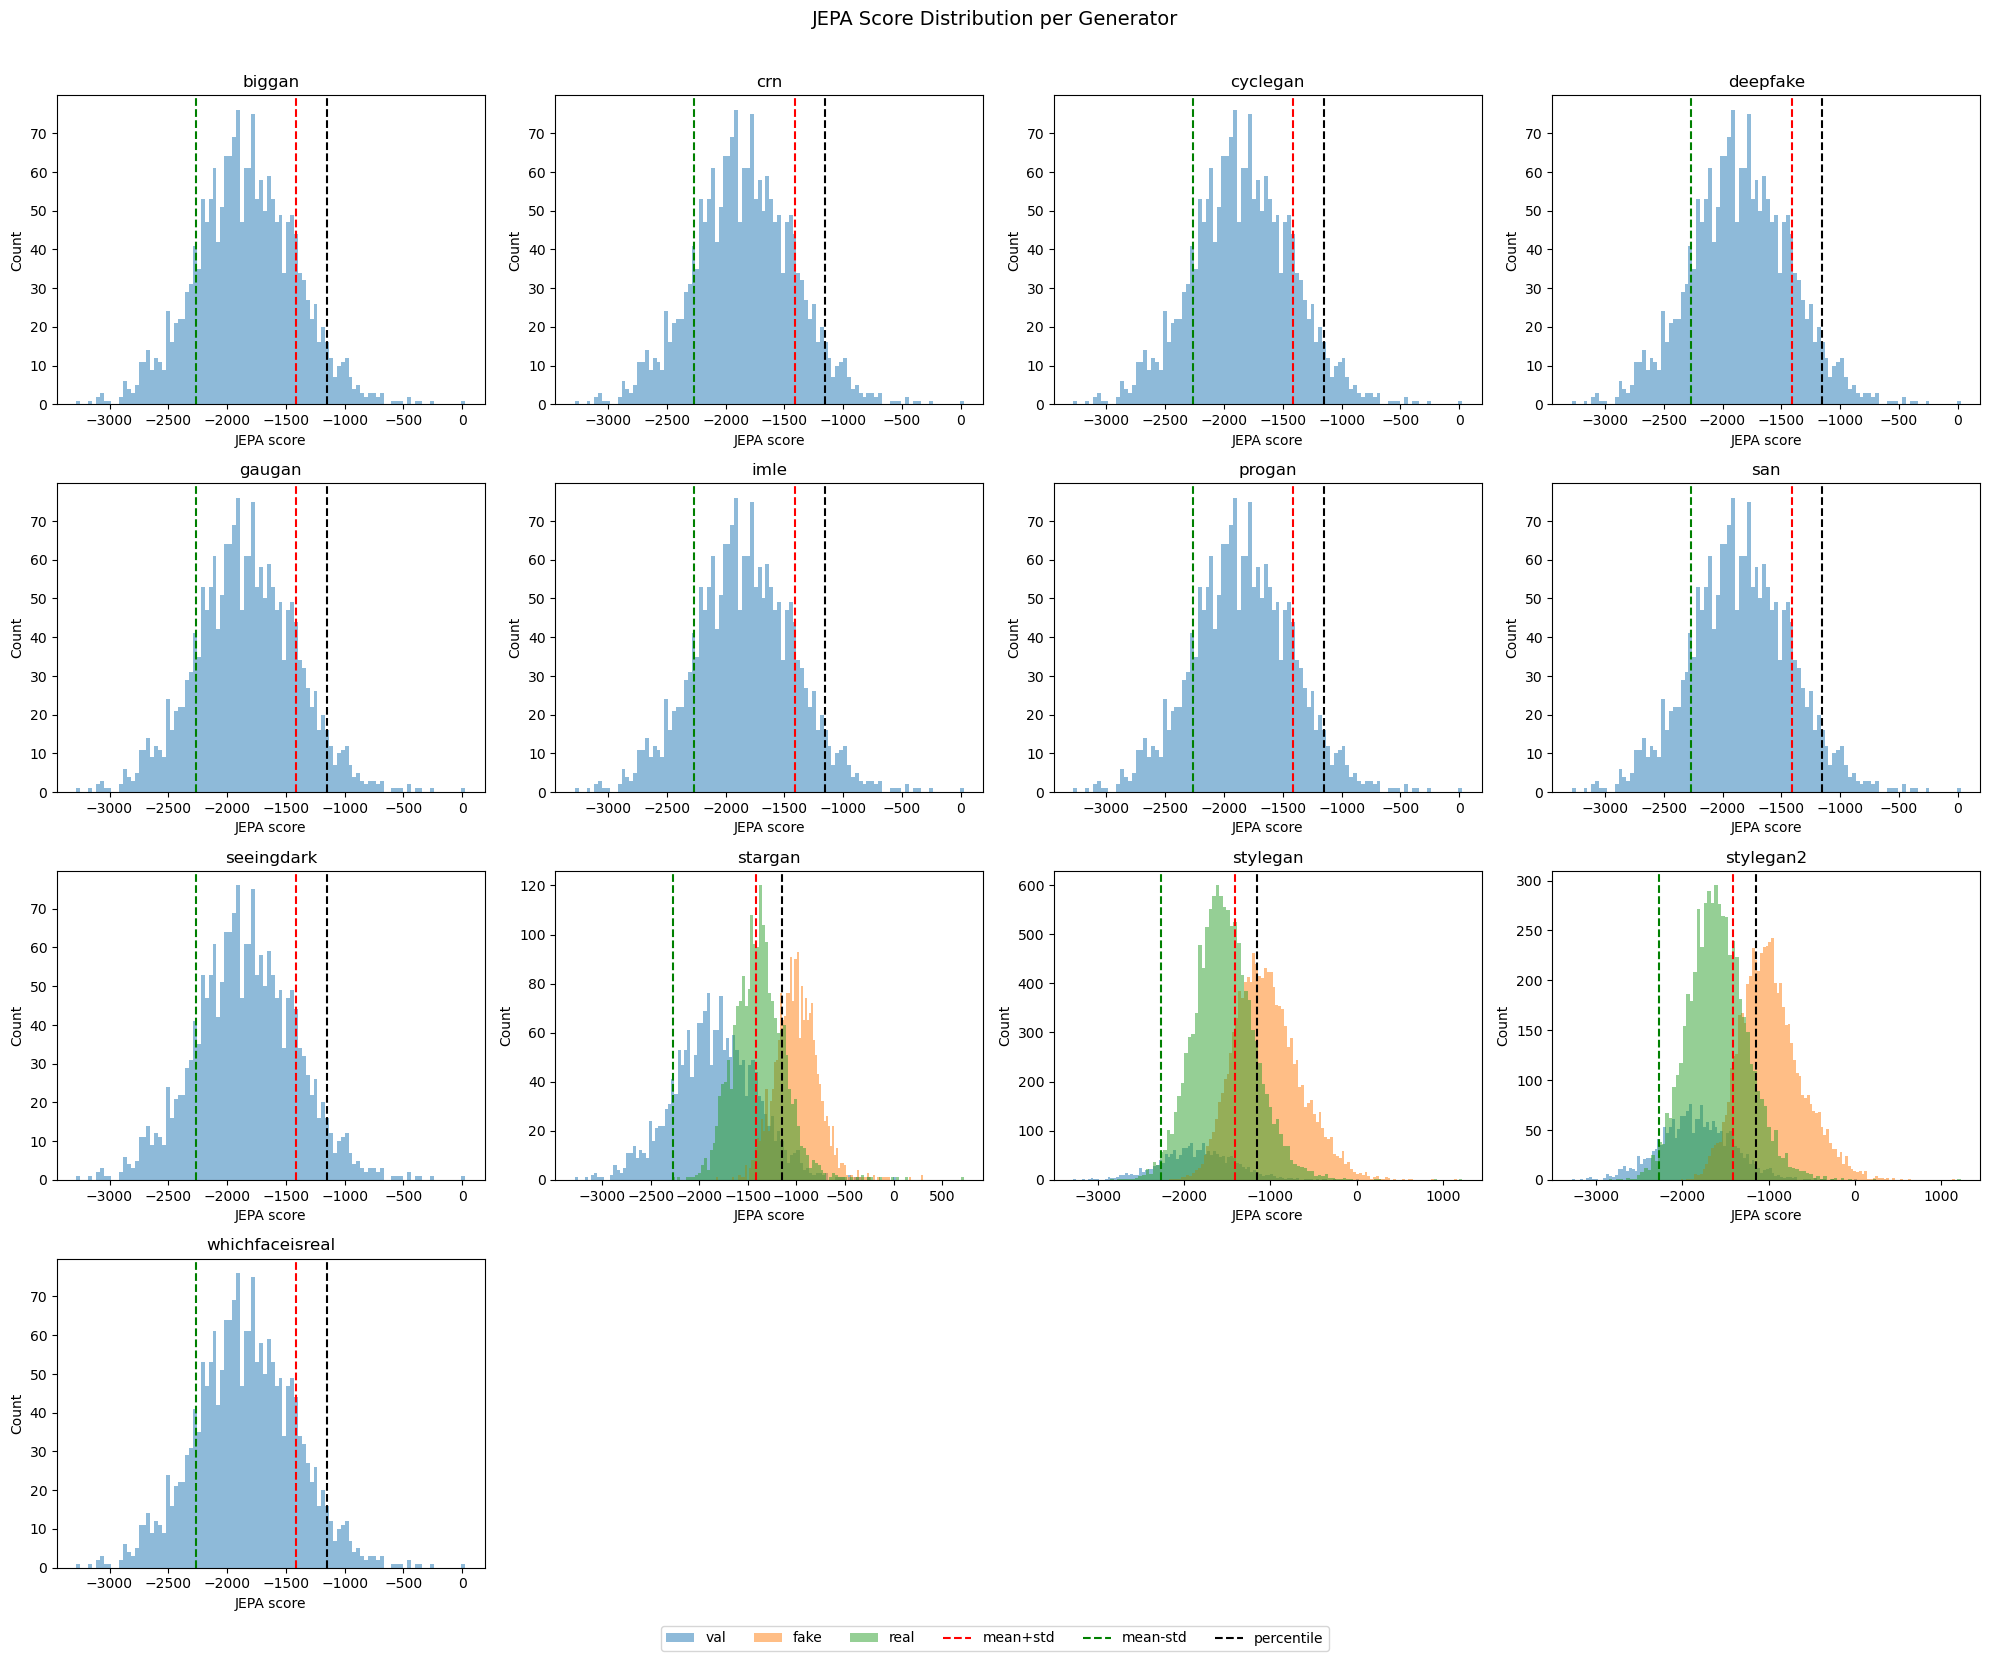


----- Performance Metrics -----
╭───────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset    │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├───────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall   │          0.7770 │           0.7484 │          0.6733 │           0.5102 │            0.7040 │             0.7385 │ 0.8403 │          0.8279 │
│ stargan   │          0.7765 │           0.7186 │          0.6668 │           0.5003 │            0.7900 │             0.7964 │ 0.8837 │          0.8466 │
│ stylegan  │          0.7771 │           0.7534 │          0.6744 │           0.5119 │            0.6879 │             0.7287 │ 0.8385 │          0.8276 │
│ stylegan2 │          0.8337 │

In [17]:
results(ds_val=val_dino2_l_14, test_results=test_dino2_l_14)

----- Validation Dataset Statistics -----
Mean: -299.0560  |  Std: 373.4853
Mean+std threshold: 74.4292
Mean-std threshold: -672.5413
95th percentile threshold: 302.3229


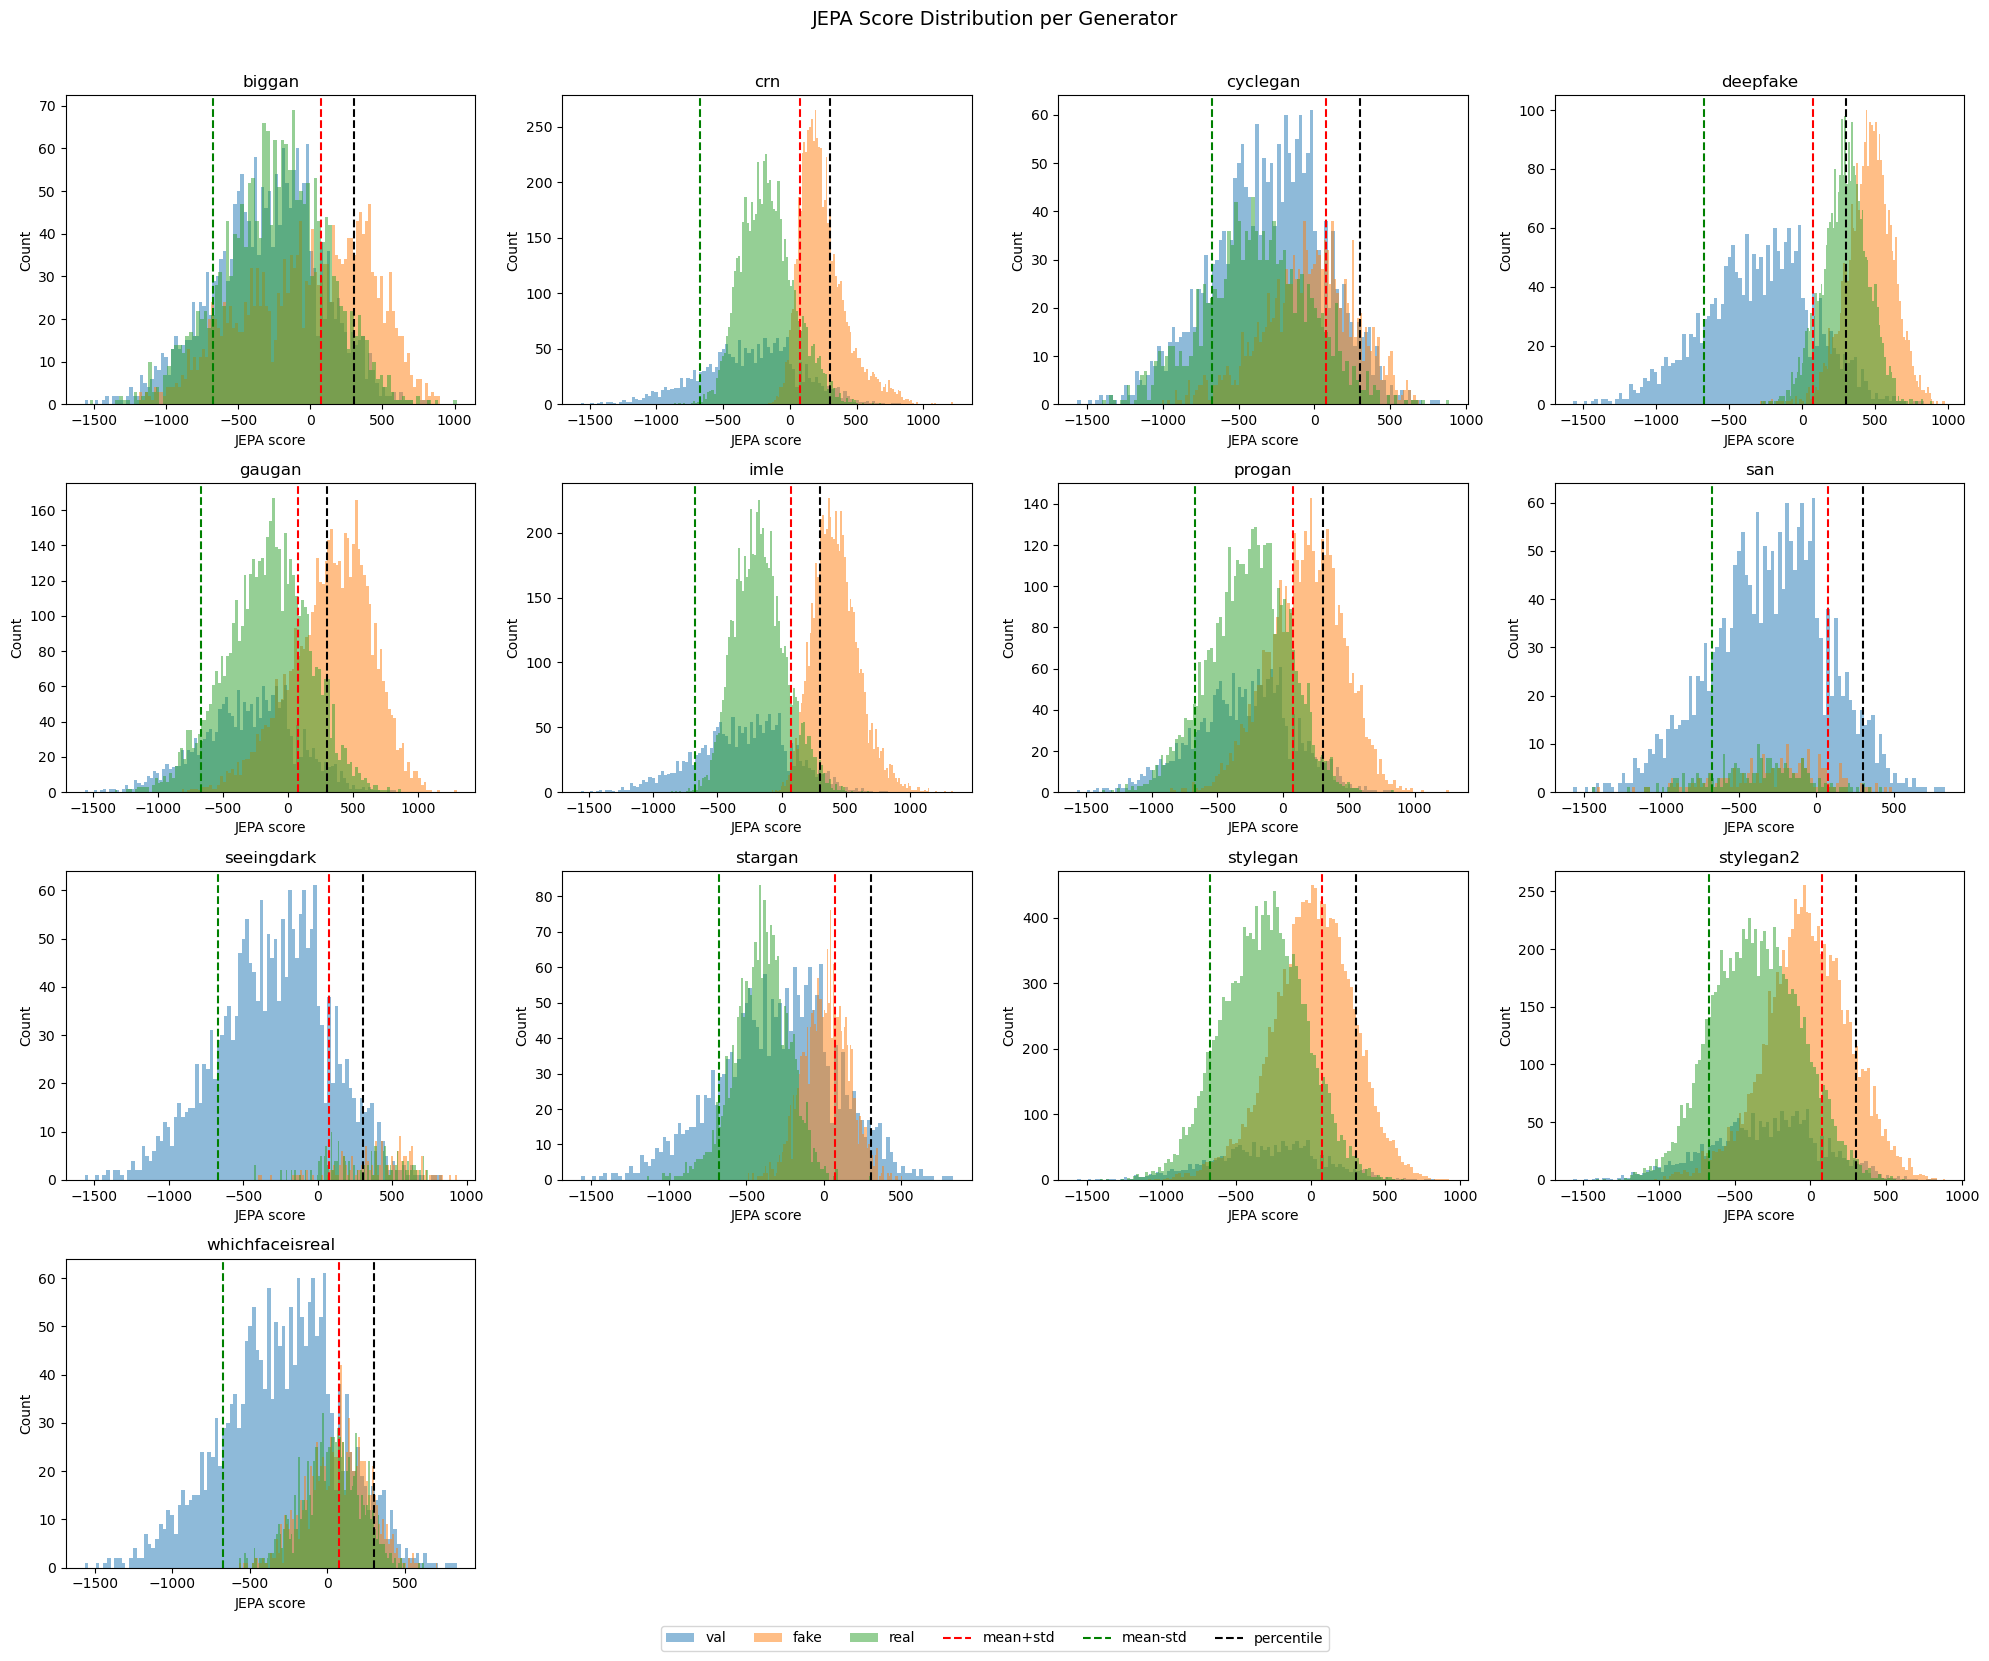


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.7201 │           0.7431 │          0.6765 │           0.5264 │            0.5072 │             0.6525 │ 0.8194 │          0.8171 │
│ biggan          │          0.5631 │           0.6372 │          0.6562 │           0.5198 │            0.4185 │             0.6095 │ 0.6588 │          0.6928 │
│ crn             │          0.8720 │           0.8725 │          0.6671 │           0.5009 │            0.4500 │             0.6395 │ 0.9423 │          0.92

In [5]:
results(ds_val=val_mc_l_14, test_results=test_mc_l_14)

----- Validation Dataset Statistics -----
Mean: -3134.9884  |  Std: 368.7384
Mean+std threshold: -2766.2500
Mean-std threshold: -3503.7268
95th percentile threshold: -2527.2212


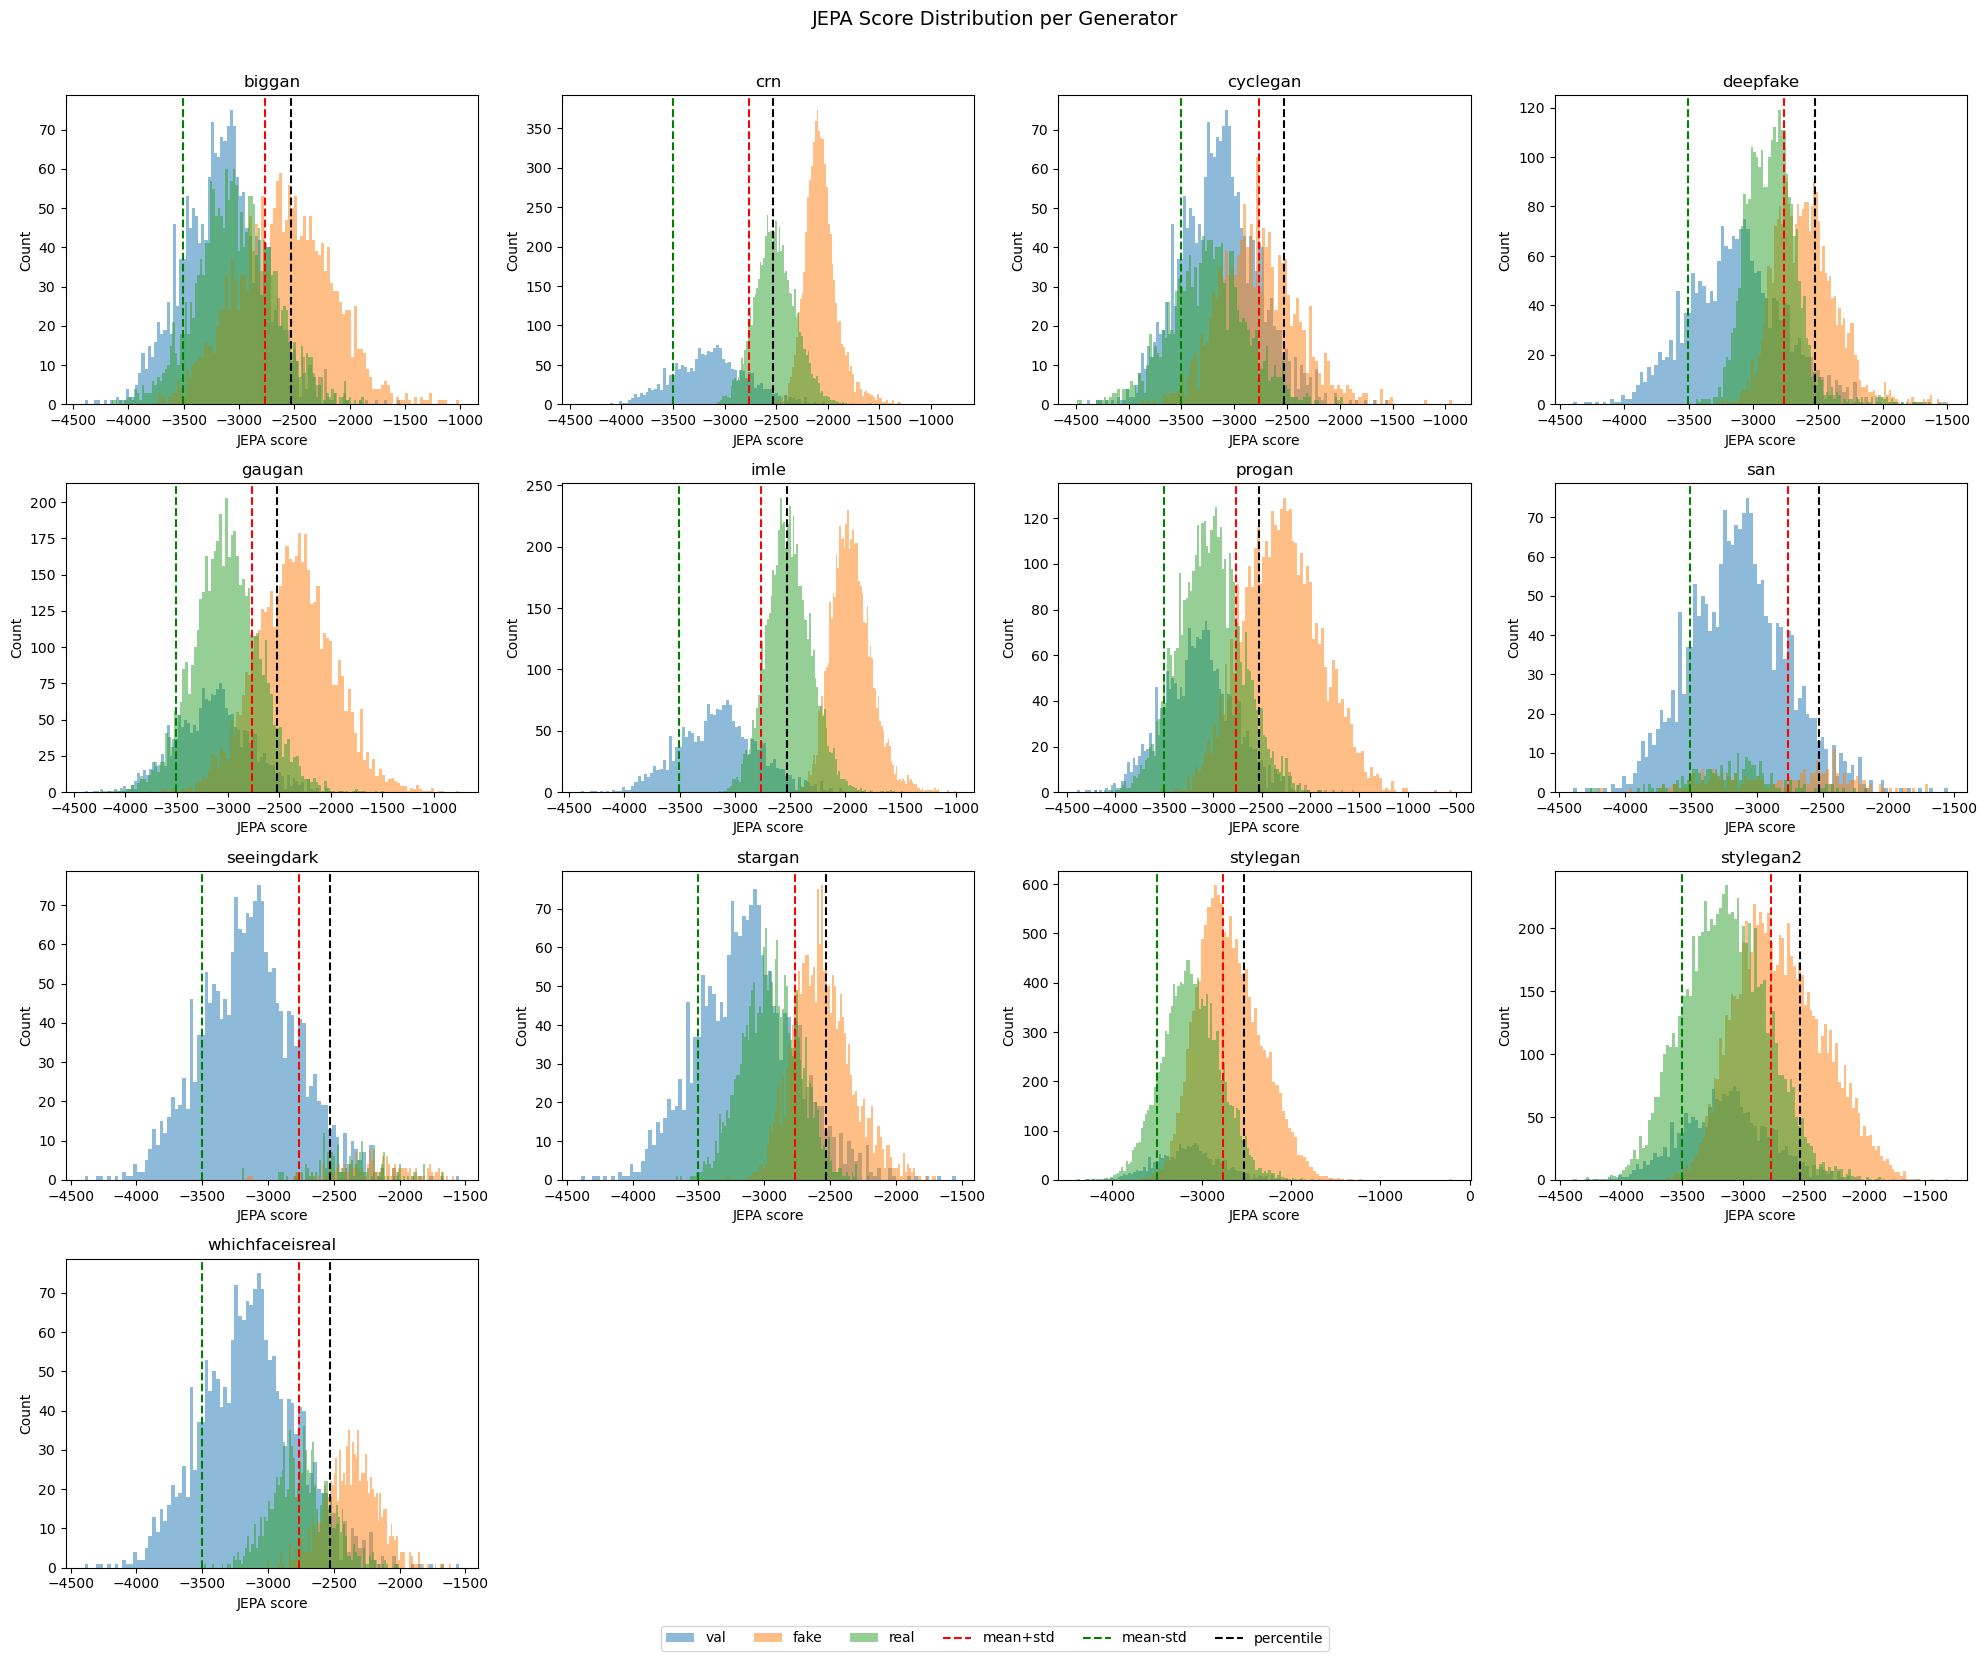


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.7148 │           0.6895 │          0.6791 │           0.5285 │            0.6747 │             0.7089 │ 0.7973 │          0.8210 │
│ biggan          │          0.6969 │           0.7147 │          0.6801 │           0.5353 │            0.5822 │             0.6827 │ 0.7846 │          0.7984 │
│ crn             │          0.6875 │           0.5455 │          0.6667 │           0.5000 │            0.7935 │             0.7398 │ 0.9628 │          0.95

In [6]:
results(ds_val=val_dino3_l_16, test_results=test_dino3_l_16)

----- Validation Dataset Statistics -----
Mean: -1780.1740  |  Std: 269.8307
Mean+std threshold: -1510.3433
Mean-std threshold: -2050.0047
95th percentile threshold: -1321.5633


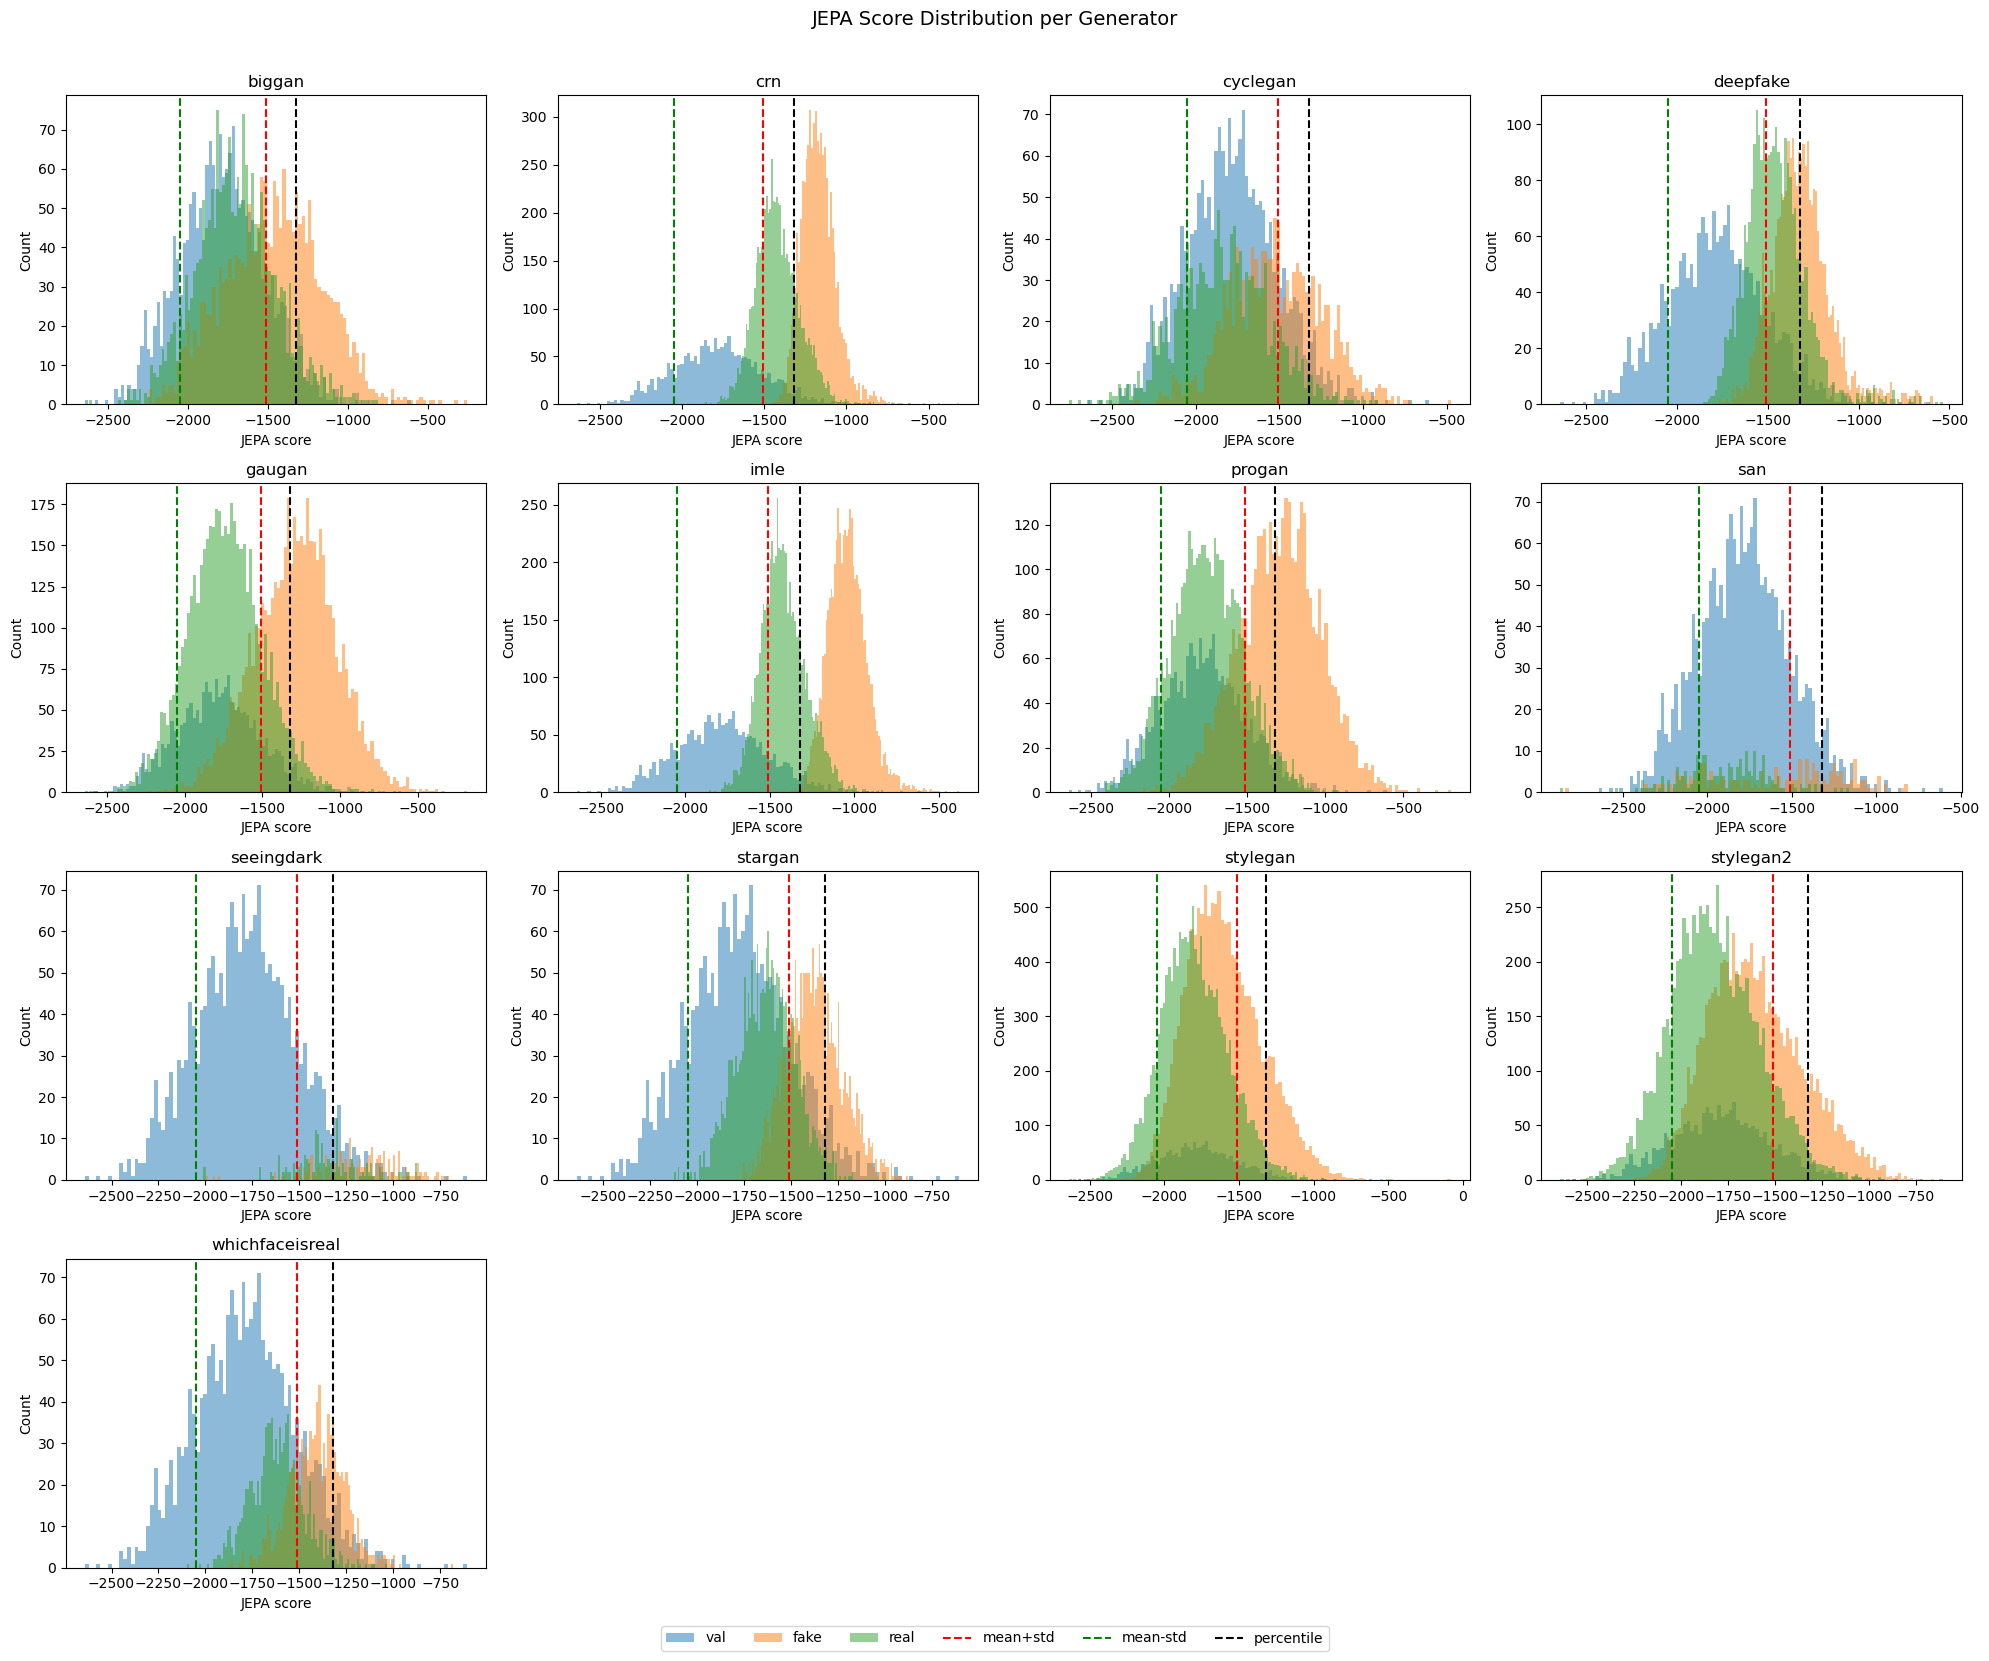


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.6828 │           0.6766 │          0.6783 │           0.5299 │            0.6355 │             0.7080 │ 0.7654 │          0.7981 │
│ biggan          │          0.6360 │           0.6773 │          0.6757 │           0.5288 │            0.4703 │             0.6295 │ 0.7253 │          0.7396 │
│ crn             │          0.7268 │           0.6241 │          0.6667 │           0.5000 │            0.8765 │             0.8664 │ 0.9304 │          0.90

In [13]:
results(ds_val=val_dino3_b_16, test_results=test_dino3_b_16)

----- Validation Dataset Statistics -----
Mean: -305.1195  |  Std: 280.4267
Mean+std threshold: -24.6929
Mean-std threshold: -585.5462
95th percentile threshold: 122.5154


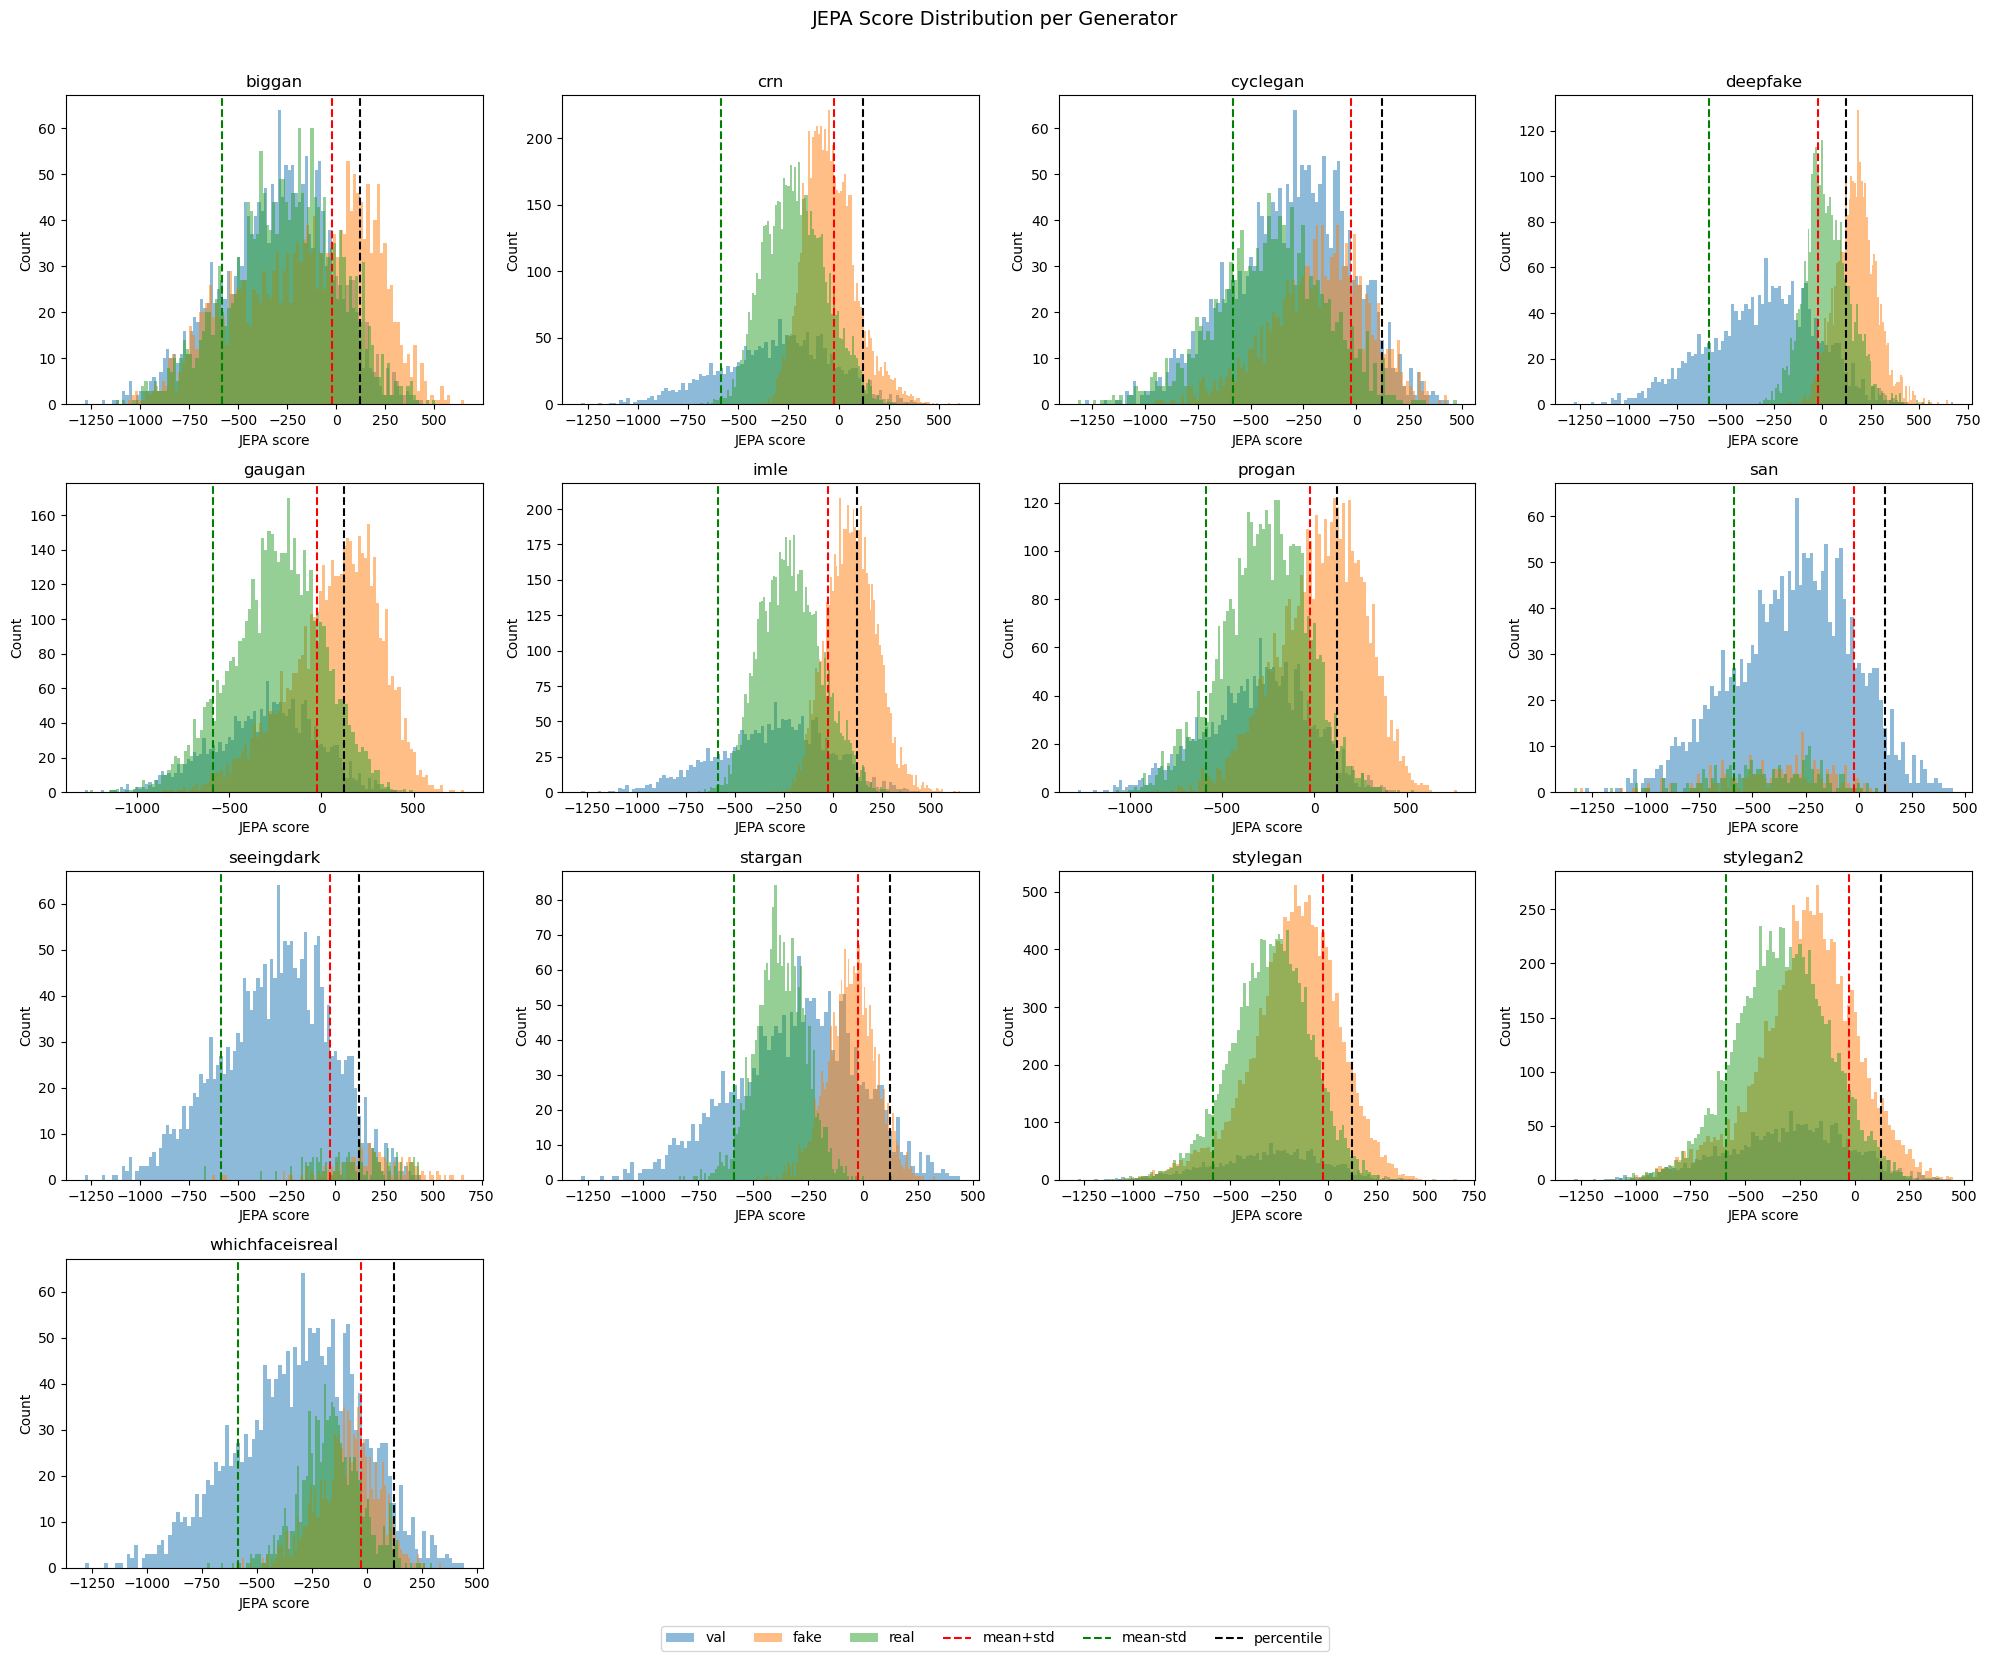


----- Performance Metrics -----
╭─────────────────┬─────────────────┬──────────────────┬─────────────────┬──────────────────┬───────────────────┬────────────────────┬────────┬─────────────────╮
│ Subset          │   F1 (mean+std) │   Acc (mean+std) │   F1 (mean-std) │   Acc (mean-std) │   F1 (percentile) │   Acc (percentile) │    AUC │   Avg Precision │
├─────────────────┼─────────────────┼──────────────────┼─────────────────┼──────────────────┼───────────────────┼────────────────────┼────────┼─────────────────┤
│ overall         │          0.6061 │           0.6754 │          0.6692 │           0.5178 │            0.3826 │             0.6045 │ 0.7525 │          0.7602 │
│ biggan          │          0.5150 │           0.6092 │          0.6339 │           0.5002 │            0.3661 │             0.5845 │ 0.6074 │          0.6468 │
│ crn             │          0.5302 │           0.6421 │          0.6673 │           0.5013 │            0.1807 │             0.5425 │ 0.8001 │          0.76

In [23]:
results(ds_val=val_mc_b_16, test_results=test_mc_b_16)

Key scores (Average Precision)

Dataset: ForenSynths

DTAD (all layers) / JEPA  
Meta(clip)-B/32: 82.0 / 73.5  
Meta(clip)-L/14: 97.4 / 81.7  
Meta(clip)-H/14: 96.4 / 75.5 (partially)  
DINOv2-L: 56.9 / -  
DINOv3-L/16: 85.4 / 81.0 (only 3 generators) -> for those already improvements over DINOv3-B/16 

MBID: 82.5 

last layer clip-L/14: 87.6 

JEPA DINOv3-B/16: 79.8 

#### Observations & Thoughts ####

1. F1 and Acc depend heavily on how similar the calibration dataset distribution is to the test distribution
2. 'whichfaceisreal' dataset is the one that fools humans the most (I would say). Metaclip can't distinguish at all, but dino 3 can
3. Score real/test score distirbutions heavily overlap right now. Might be partly, because some classes have in general a higher/lower score. Might need to focus on local and not global comaprisons
4. Very good: Distributions don't flip sides. Fake images always get higher scores

Question: 
- Will a normalisation term by e.g. entropy within the image help?
- What do I need to save after each run, such that I can test many approaches of mine? I want to reduce the time


Axis of improvements
1. Make calibration dataset more diverse
2. Use most similar images as reference for classification
3. Use better foundation models: e.g. with more activated directions of the input Jacobian (see geometry paper)
4. Dissect the score and look at eigenvalues: how many? how fast are they shrinking? density estimation? focus on ones relating to hig frequency spectrum?

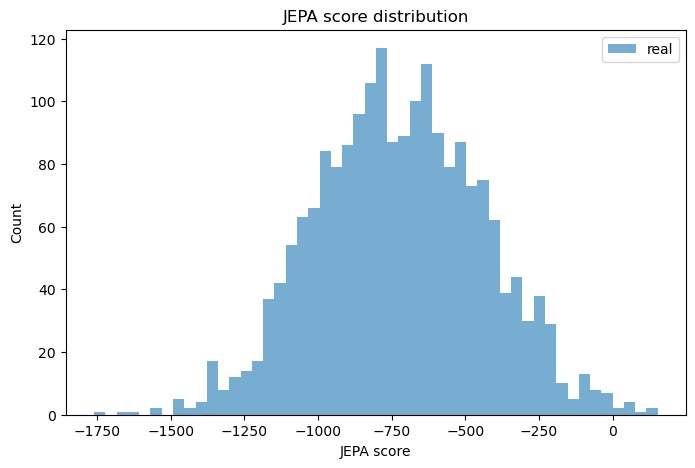

----- Validation Dataset Statistics -----
Mean: -722.6715443840027
Standard Deviation: 284.51912577822765
Mean + std threshold for real/fake decision: -438.15241860577504
Mean - std threshold for real/fake decision: -1007.1906701622304
95th percentile threshold: -251.07501983642587
----- Performance Metrics -----
F1 (mean plus std): 0.6253586641891977
Accuracy (mean plus std): 0.6718772487241086
F1 (mean minus std): 0.6699856027885125
Accuracy (mean minus std): 0.5178514098462288
F1 (percentile): 0.3654876741693462
Accuracy (percentile): 0.593663164653655
AUC: 0.7342371632225172
Average precision: 0.735346602562788


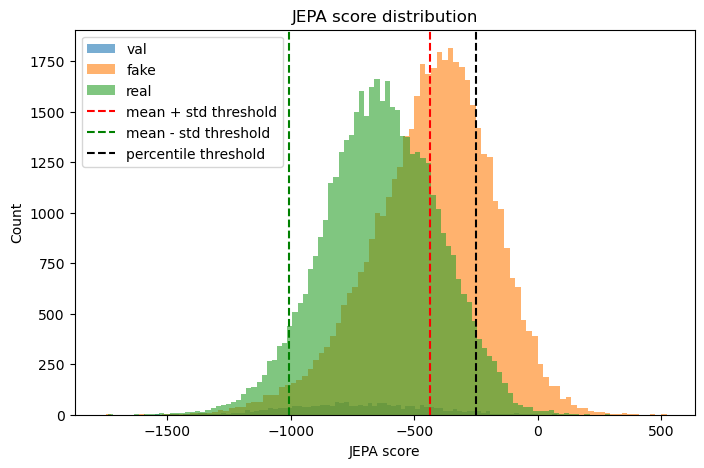

In [ ]:
results(ds_val=val_mc_b_32, test_results=test_mc_b_32)

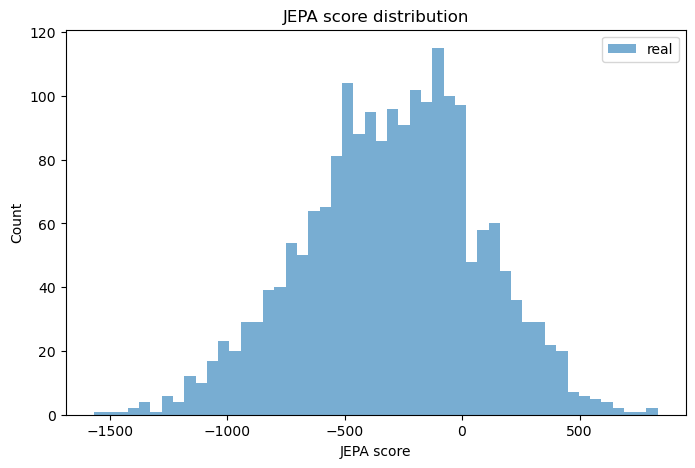

----- Validation Dataset Statistics -----
Mean: -299.0560245532989
Standard Deviation: 373.48526991375326
Mean + std threshold for real/fake decision: 74.42924536045433
Mean - std threshold for real/fake decision: -672.5412944670522
95th percentile threshold: 302.3229202270507
----- Performance Metrics -----
F1 (mean plus std): 0.7200723763570567
Accuracy (mean plus std): 0.743094687199017
F1 (mean minus std): 0.676512178338362
Accuracy (mean minus std): 0.5264090159306535
F1 (percentile): 0.5072447842263073
Accuracy (percentile): 0.652503625635178
AUC: 0.819368803521686
Average precision: 0.8171398694972128


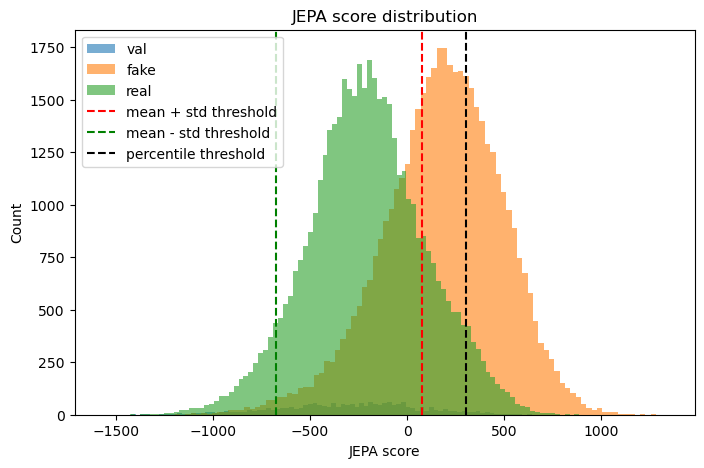

In [ ]:
results(ds_val=val_mc_l_14, test_results=test_mc_l_14)

that fake images have higher values makes sense, as it is a result of more expansion = sparser region

In [ ]:
airplane = test_dino3_b_16[test_dino3_b_16["img_path"].str.contains("stylegan2")].copy()
airplane

,label,score,img_path,prediction_mean_plus_std,prediction_mean_minus_std,prediction_percentile
15980,1.0,-1938.023682,stylegan2/horse/1_fake/000000.png,0,1,0
15981,1.0,-1213.717529,stylegan2/horse/1_fake/000001.png,1,1,1
15982,1.0,-1462.068726,stylegan2/horse/1_fake/000002.png,1,1,0
15983,1.0,-1032.218994,stylegan2/horse/1_fake/000003.png,1,1,1
15984,1.0,-1673.691895,stylegan2/horse/1_fake/000004.png,0,1,0
...,...,...,...,...,...,...
31951,0.0,-1509.370850,stylegan2/cat/0_real/19957.png,1,1,0
31952,0.0,-1819.363037,stylegan2/cat/0_real/19982.png,0,1,0
31953,0.0,-1744.488159,stylegan2/cat/0_real/19983.png,0,1,0
31954,0.0,-1385.223755,stylegan2/cat/0_real/19985.png,1,1,0


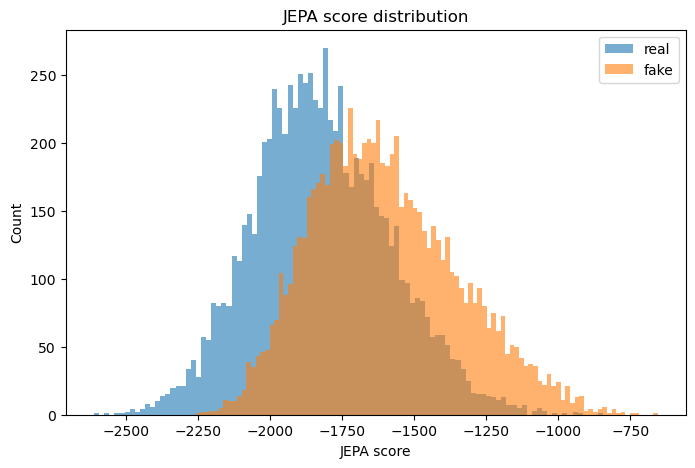

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(airplane[airplane["label"] == 0].score, bins=100, alpha=0.6, label="real")
plt.hist(airplane[airplane["label"] == 1].score, bins=100, alpha=0.6, label="fake")
#plt.hist(real_scores, bins=100, alpha=0.6, label="cal")

#plt.axvline(x=mean_plus_std, color="red", linestyle="--", label="mean + std threshold")
#plt.axvline(x=mean_minus_std, color="green", linestyle="--", label="mean - std threshold")
#plt.axvline(x=percentile, color="black", linestyle="--", label="percentile threshold")

plt.xlabel("JEPA score")
plt.ylabel("Count")
plt.title("JEPA score distribution")
plt.legend()

plt.show()

In [ ]:
base_dir = "/ceph/tischuet/replication_data/ForenSynths"
airplane_sorted = airplane.sort_values(by=["score"])

# Assuming airplane_sorted is already sorted by score
lowest_5 = airplane_sorted.head(5)
highest_5 = airplane_sorted.tail(5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Top row: lowest 5 scores
for i, (_, row) in enumerate(lowest_5.iterrows()):
    img = mpimg.imread(os.path.join(base_dir, row["img_path"]))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Score: {row['score']:.2f}\nLabel: {row['label']}", fontsize=10)
    axes[0, i].set_xlabel(row["img_path"], fontsize=7, wrap=True)
    axes[0, i].axis("off")

# Bottom row: highest 5 scores
for i, (_, row) in enumerate(highest_5.iterrows()):
    img = mpimg.imread(os.path.join(base_dir, row["img_path"]))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Score: {row['score']:.2f}\nLabel: {row['label']}", fontsize=10)
    axes[1, i].set_xlabel(row["img_path"], fontsize=7, wrap=True)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Lowest 5", fontsize=14, fontweight="bold", labelpad=10)
axes[1, 0].set_ylabel("Highest 5", fontsize=14, fontweight="bold", labelpad=10)

plt.suptitle("Lowest vs Highest Scoring Airplanes", fontsize=16, fontweight="bold")
plt.tight_layout()
#plt.savefig("lowest_vs_highest_5.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'airplane' is not defined